# Overtake.GP · Anàlisi de dades

---

## Estructura del notebook

| Bloc | Contingut |
|------|-----------|
| **0. Configuració** | Imports, constants i càrrega de dades |
| **1. KPIs i SMART** | Verificació d'objectius i anàlisi descriptiu |
| **2. Tests estadístics** | Impacte d'esdeveniments clau (Mann-Whitney) |
| **3. Anàlisi de continguts** | Format, dia, hora, scatterplot, pairplot |
| **3.5 NER** | Entitats als captions, núvol de paraules, rànquing de pilots |
| **3.6 CLIP** | Classificació visual de posts |
| **4. Benchmarking** | Comparativa de creixement amb comptes referents |
| **5. Model predictiu** | Holt-Winters · projecció 6 mesos |
| **6. Conclusions** | Síntesi global · pendent de dades finals |
| **Annex A** | API Metricool · infraestructura i demografia |
| **Annex B** | MySQL · procés explorat i descartat |


---
# Bloc 0 · Configuració i càrrega de dades

Centralitzem aquí tots els imports, constants i càrregues de dades.

*Tots els imports del projecte es troben en aquesta cel·la per facilitar la detecció d'errors de dependències en iniciar el notebook.*


In [168]:
# ── Imports ────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.stats import spearmanr
from datetime import datetime, timezone
import json
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pycountry
import plotly.io as pio
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess

# ── NLP / Vision (Bloc 3.5 i 3.6) ──────────────────────────────────────────
from transformers import pipeline, CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO
import torch
from tqdm import tqdm
tqdm.pandas()
from wordcloud import WordCloud

import os, webbrowser



Configuració global de les visualitzacions

In [99]:
# Càrrega de fonts locals
fonts_dir = Path("fonts")
for font_file in fonts_dir.glob("*.ttf"):
    fm.fontManager.addfont(str(font_file))
for font_file in fonts_dir.glob("*.otf"):
    fm.fontManager.addfont(str(font_file))

# ── Configuració global · Matplotlib ─────────────────────────────────────────
import matplotlib as mpl

mpl.rcParams['font.family']        = 'Barlow'
mpl.rcParams['axes.titlesize']     = 14
mpl.rcParams['font.weight']        = 'medium'
mpl.rcParams['axes.titleweight']   = 'bold'
mpl.rcParams['axes.labelweight']   = 'medium'
mpl.rcParams['axes.labelsize']     = 11
mpl.rcParams['axes.labelcolor']    = '#222222'
mpl.rcParams['text.color']         = '#222222'
mpl.rcParams['xtick.labelsize']    = 9
mpl.rcParams['ytick.labelsize']    = 9
mpl.rcParams['xtick.color']        = '#222222'
mpl.rcParams['ytick.color']        = '#222222'
mpl.rcParams['figure.facecolor']   = '#F7F7F7'
mpl.rcParams['axes.facecolor']     = '#F7F7F7'
mpl.rcParams['axes.spines.top']    = False
mpl.rcParams['axes.spines.right']  = False
mpl.rcParams['grid.alpha']         = 0.3
mpl.rcParams['grid.color']         = '#cccccc'
mpl.rcParams['figure.dpi']         = 150

# ── Configuració global · Plotly ──────────────────────────────────────────────
import plotly.io as pio

pio.templates["overtake"] = pio.templates["plotly_white"]
pio.templates["overtake"].layout.font = dict(
    family="Barlow, sans-serif",
    size=12,
    color="#222222"
)
pio.templates["overtake"].layout.title.font = dict(
    family="Barlow, sans-serif",
    size=15,
    color="#111111"
)
pio.templates["overtake"].layout.paper_bgcolor = '#F7F7F7'
pio.templates["overtake"].layout.plot_bgcolor  = '#F7F7F7'
pio.templates["overtake"].layout.xaxis = dict(
    gridcolor='#eeeeee',
    linecolor='#cccccc',
    tickfont=dict(color='#222222')
)
pio.templates["overtake"].layout.yaxis = dict(
    gridcolor='#eeeeee',
    linecolor='#cccccc',
    tickfont=dict(color='#222222')
)

pio.templates.default = "overtake"

print("Configuració global aplicada ✓")


Configuració global aplicada ✓


Definició de constants globals

In [100]:
# ── Constants ───────────────────────────────────────────

# Paths dels fitxers de dades
DATA_DIR = ''   # canvia si els CSV estan en una subcarpeta

FITXERS_COMPTES = {
    'overtake'            : 'overtake.gp-historical-stats.csv',
    'everithingmotoracing': 'everythingmotoracing-historical-stats.csv',
    'motociclismo_es'     : 'motociclismo_es-historical-stats.csv',
    'moto_gp'             : 'motogp-historical-stats.csv',
    'motorsportcom'       : 'motorsportcom-historical-stats.csv',
    'motorspain_77'       : 'motospain77-historical-stats.csv',
    'brake_gp'            : 'brake.gp-historical-stats.csv',
}

FITXER_POSTS = 'instagram-posts_2025-05-31_2026-05-31.csv'

# Dates clau del projecte
DATA_INICI_TFG    = '2025-09-01'   # inici periode academic
DATA_INICI_LLARG  = '2024-01-01'   # inici periode llarg benchmarking
DATA_INICI_CURT   = '2024-11-12'   # inici periode curt (brake_gp disponible)


## Càrrega de dades

Carreguem tots els datasets en aquesta secció. La funció `import_csv_comptes` 
unifica els fitxers dels comptes referents en un sol DataFrame, afegint la columna `account`.


In [101]:
# ── Funció de càrrega ────────────────────────────────────
def import_csv_comptes(diccionari):
    """
    Importa múltiples CSVs amb el mateix format, afegeix la columna 'account'
    i els concatena en un únic DataFrame.

    Paràmetres:
        diccionari (dict): {nom_compte: fitxer_csv}
    Retorna:
        pd.DataFrame: DataFrame unificat amb columna 'account'
    """
    llista = []
    for nom, fitxer in diccionari.items():
        temp = pd.read_csv(DATA_DIR + fitxer)
        temp.columns = temp.columns.str.strip().str.lstrip('\ufeff')
        temp['account'] = nom
        llista.append(temp)
        print(f'  {nom}: {len(temp)} files')
    return pd.concat(llista, ignore_index=True)


# ── Dataset 1: comptes comparatius (InstaTrack) ───────────
print('Carregant comptes...')
df_comptes = import_csv_comptes(FITXERS_COMPTES)

# ── Dataset 2: posts Overtake.GP (Metricool) ──────────────
print('\nCarregant posts...')
posts = pd.read_csv(DATA_DIR + FITXER_POSTS,
                    sep=';', quotechar='"',
                    on_bad_lines='skip', encoding='utf-8')
posts.columns = posts.columns.str.strip().str.lstrip('\ufeff')
print(f'  posts: {len(posts)} files')

# ── Dataset 3: sèrie temporal Overtake.GP ────────────────
hist = df_comptes[df_comptes['account'] == 'overtake'].copy()

print(f'\nTotal files df_comptes : {len(df_comptes)}')
print(f'Total posts            : {len(posts)}')
print(f'Total dies hist        : {len(hist)}')

# ── Paleta de colors · demografia ────────────────────────────────────────────
colors_pais = ['#1D9E75','#4A90D9','#E67E22','#9B59B6','#E24B4A',
               '#F1C40F','#1ABC9C','#E91E63',"#aaaaaaff"]


Carregant comptes...
  overtake: 883 files
  everithingmotoracing: 2018 files
  motociclismo_es: 1060 files
  moto_gp: 2779 files
  motorsportcom: 2269 files
  motorspain_77: 1893 files
  brake_gp: 567 files

Carregant posts...
  posts: 419 files

Total files df_comptes : 11469
Total posts            : 419
Total dies hist        : 883


Netegem i fem les conversions a les columnes de dataframes on sigui neccesari. També definim dataframes amb rangs concrets que ens ajudaran en les futures analisis.

In [102]:
# ── Neteja unificada ─────────────────────────────────────

# Conversions de tipus
df_comptes['date'] = pd.to_datetime(df_comptes['date'])

for col in ['engagement_rate', 'comments_to_likes_ratio']:
    if df_comptes[col].dtype == object:
        df_comptes[col] = df_comptes[col].str.replace('%', '').astype(float)
df_comptes = df_comptes.sort_values(['account','date']).reset_index(drop=True)

# Columnes derivades
df_comptes['daily_gain']    = df_comptes.groupby('account')['followers_count'].diff()
df_comptes['posts_per_day'] = df_comptes['weekly_posts'] / 7
df_comptes['month']         = df_comptes['date'].dt.to_period('M')
df_comptes['growth_rate']   = (
    df_comptes['daily_gain'] /
    df_comptes['followers_count'].replace(0, np.nan) * 100
)

# Posts: conversions de tipus
posts['Timestamp'] = pd.to_datetime(posts['Timestamp'])
for col in ['Engagement','Likes','Views','Reach (Organic)',
            'Saved','Comments','Shares','Interactions']:
    posts[col] = pd.to_numeric(
        posts[col].astype(str).str.replace(',','.'), errors='coerce'
    )
posts['hour']     = posts['Timestamp'].dt.hour
posts['weekday']  = posts['Timestamp'].dt.day_name()
posts['month']    = posts['Timestamp'].dt.to_period('M')
posts['hour_bin'] = pd.cut(posts['hour'],
                            bins=[0,6,10,13,17,21,24],
                            labels=['0-6h','7-10h','11-13h','14-17h','18-21h','22-24h'])

# Sèrie temporal Overtake (actualitzada amb columnes derivades)
hist = df_comptes[df_comptes['account'] == 'overtake'].copy().reset_index(drop=True)

# Subconjunts per benchmarking
df_llarg = df_comptes[
    (df_comptes['date'] >= DATA_INICI_LLARG) &
    (df_comptes['account'] != 'brake_gp')
].copy()
df_llarg['index_100'] = df_llarg.groupby('account')['followers_count'].transform(
    lambda x: x / x.iloc[0] * 100
)

df_curt = df_comptes[df_comptes['date'] >= DATA_INICI_CURT].copy()
df_curt['index_100'] = df_curt.groupby('account')['followers_count'].transform(
    lambda x: x / x.iloc[0] * 100
)

print('Neteja i transformacions completades')
print(f'  df_comptes : {len(df_comptes):,} files')
print(f'  df_llarg   : {len(df_llarg):,} files · {df_llarg["account"].nunique()} comptes')
print(f'  df_curt    : {len(df_curt):,} files · {df_curt["account"].nunique()} comptes')
print(f'  hist       : {len(hist):,} files')
print(f'  posts      : {len(posts):,} posts')

# ── Dataset 4: demografia Overtake.GP (Metricool API) ─────
print('\nCarregant demografia...')
with open(DATA_DIR + 'metricool_demografia.json', 'r', encoding='utf-8') as f:
    demo_raw = json.load(f)
print(f'  gender:  {len(demo_raw["gender"])} categories')
print(f'  age:     {len(demo_raw["age"])} franges')
print(f'  country: {len(demo_raw["country"])} països')
print(f'  city:    {len(demo_raw["city"])} ciutats')


Neteja i transformacions completades
  df_comptes : 11,469 files
  df_llarg   : 5,293 files · 6 comptes
  df_curt    : 3,964 files · 7 comptes
  hist       : 883 files
  posts      : 419 posts

Carregant demografia...
  gender:  3 categories
  age:     8 franges
  country: 45 països
  city:    20 ciutats


---
# Bloc 1 · Anàlisi descriptiu i KPIs

## Fonts de dades

Per a aquesta anàlisi fem servir dos datasets complementaris:

- **InstaTrack** · seguiment diari del compte des del 31 de desembre de 2023 fins a l'actualitat. Inclou 7 comptes del sector del motociclisme amb un total de ~11.000 registres. S'utilitza per als KPIs basats en evolució temporal de seguidors i freqüència de publicació.

- **Metricool** · registre individual de publicacions des d'agost de 2025 fins a l'actualitat, amb informació de més de 419 posts. S'utilitza per al KPI d'engagement, que requereix dades a nivell de post individual.

- **Metricool API** · instantània demogràfica de l'audiència capturada el maig de 2026. Inclou distribució per gènere, edat, país i ciutat.

---
## Bloc 1.1 · Evolució i creixement

Seguiment de l'evolució del compte des dels seus inicis fins a l'actualitat. Les dades de posts/dia combinen dos fonts: InstaTrack per al període gen 2024 – jul 2025, i Metricool per al període ago 2025 – avui.

### Càlcul de posts diaris · Font combinada

Els posts per dia es calculen combinant dues fonts:
- **InstaTrack** (gen 2024 – jul 2025): diferència diària del total acumulat de posts (`media_count`). Els pics anòmals (>5 posts/dia) s'eliminen per ser errors de l'API.
- **Metricool** (ago 2025 → avui): recompte directe dels posts individuals.

Aquesta combinació permet cobrir tot el període histèric del compte.


In [103]:
# Posts diaris · combinació de fonts
# Període gen 2024 → jul 2025: posts acumulats d'InstaTrack (diferència diària)
# Període ago 2025 → 31 maig 2026: posts individuals de Metricool

# Font 1: InstaTrack — calculem posts diaris des de media_count acumulat
hist_posts = hist[['date', 'media_count']].copy()
hist_posts = hist_posts.sort_values('date')
hist_posts['posts_dia'] = hist_posts['media_count'].diff().clip(lower=0)

# Font 2: Metricool — posts individuals per dia
posts_dia_metricool = posts.groupby(
    posts['Timestamp'].dt.date
).size().reset_index()
posts_dia_metricool.columns = ['date', 'posts_dia']
posts_dia_metricool['date'] = pd.to_datetime(posts_dia_metricool['date'])

# Combinem — prioritzem Metricool quan hi ha solapament
data_tall = pd.Timestamp('2025-08-01')
hist_posts_tall = hist_posts[hist_posts['date'] < data_tall][['date', 'posts_dia']]
posts_dia_combined = pd.concat([hist_posts_tall, posts_dia_metricool], ignore_index=True)
posts_dia_combined = posts_dia_combined.sort_values('date').reset_index(drop=True)

print(f"Posts diaris combinats: {len(posts_dia_combined)} dies")
print(f"Rang: {posts_dia_combined['date'].min()} → {posts_dia_combined['date'].max()}")
print(f"Mitjana posts/dia: {posts_dia_combined['posts_dia'].mean():.2f}")
print(posts_dia_combined[posts_dia_combined['posts_dia'] > 0].head(10))

Posts diaris combinats: 855 dies
Rang: 2023-12-31 00:00:00 → 2026-05-31 00:00:00
Mitjana posts/dia: 1.20
         date  posts_dia
1  2024-01-01        2.0
2  2024-01-02        1.0
4  2024-01-04        1.0
12 2024-01-12        1.0
14 2024-01-14        1.0
19 2024-01-19        1.0
21 2024-01-21        1.0
22 2024-01-22        2.0
23 2024-01-23        1.0
24 2024-01-24        2.0


Fem comprovacions, i detectem que alguns dies apareixen una quantitat de posts que no es corresponen a la realitat en el periode mes antic. Limitem a 5 posts per dia.

In [104]:
# Detectem els pics anòmals
pics = posts_dia_combined[posts_dia_combined['posts_dia'] > 5].sort_values('posts_dia', ascending=False)
print(pics.head(15))

          date  posts_dia
111 2024-04-20       12.0
84  2024-03-24       11.0
135 2024-05-14       10.0
160 2024-06-08        9.0
118 2024-04-27        9.0
70  2024-03-10        8.0
833 2026-05-10        8.0
324 2024-11-19        7.0
790 2026-03-28        7.0
132 2024-05-11        6.0
124 2024-05-03        6.0


In [105]:
# Verifiquem el pic de 2026-05-10 — hauria de ser real (GP Catalunya)
print(posts[posts['Timestamp'].dt.date == pd.Timestamp('2026-05-10').date()][['Timestamp', 'Content']].to_string())

# I un pic de 2024 per veure si és error
print(posts[posts['Timestamp'].dt.date == pd.Timestamp('2024-04-20').date()][['Timestamp', 'Content']].to_string())

             Timestamp                                                                                                                                                                                                                                                                                                                                                                                                                    Content
52 2026-05-10 18:01:00                                                                                                                                                                                                                                                                                                                                 📊 STANDINGS AFTER ROUND 5\n\n📸 Gold & Goose\n#MotoGP #FrenchGP #LeMans #motorcycle #racing
53 2026-05-10 15:59:00                                                                                     🌟 It’s no exaggeration to

In [106]:
# Filtrem pics anòmals només a la part d'InstaTrack (abans ago 2025)
data_tall = pd.Timestamp('2025-08-01')
mask_instatrack = posts_dia_combined['date'] < data_tall
posts_dia_combined.loc[mask_instatrack, 'posts_dia'] = (
    posts_dia_combined.loc[mask_instatrack, 'posts_dia'].clip(upper=5)
)

print(posts_dia_combined[posts_dia_combined['posts_dia'] > 4].sort_values('posts_dia', ascending=False).head(10))

          date  posts_dia
833 2026-05-10        8.0
790 2026-03-28        7.0
90  2024-03-30        5.0
84  2024-03-24        5.0
106 2024-04-15        5.0
111 2024-04-20        5.0
118 2024-04-27        5.0
97  2024-04-06        5.0
70  2024-03-10        5.0
128 2024-05-07        5.0


### Figura 1.1 · Evolució de seguidors

Gràfic interactiu (Plotly) que mostra l'evolució diària de seguidors combinada amb el nombre de posts publicats per dia. Inclou selector de rang temporal i tooltip amb valors exactes per dia.


In [157]:
# ── Bloc 1.1 · Evolució de seguidors ─────────────────────────────────────────
# Seguiment diari del nombre de seguidors d'Overtake.GP
# Font: InstaTrack · gen 2024 → maig 2026
# Posts/dia: InstaTrack (gen 2024 – jul 2025) + Metricool (ago 2025 → maig 2026)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# ── Línia de seguidors ───────────────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=hist['date'],
        y=hist['followers_count'],
        name='Seguidors',
        line=dict(color='#1D9E75', width=2),
        fill='tozeroy',
        fillcolor='rgba(29,158,117,0.1)',
        hovertemplate='<b>%{x|%d %b %Y}</b><br>Seguidors: %{y:,.0f}<extra></extra>'
    ),
    secondary_y=False
)

# ── Barres de posts per dia · font combinada ─────────────────────────────────
fig.add_trace(
    go.Bar(
        x=posts_dia_combined['date'],
        y=posts_dia_combined['posts_dia'],
        name='Posts/dia',
        marker_color='rgba(255,140,0,0.85)',
        marker_line_width=0,
        hovertemplate='<b>%{x|%d %b %Y}</b><br>Posts: %{y:.0f}<extra></extra>'
    ),
    secondary_y=True
)

# ── KPIs calculats ───────────────────────────────────────────────────────────
seg_actual  = hist['followers_count'].iloc[-1]
seg_inicial = hist['followers_count'].iloc[0]
creix_pct   = (seg_actual - seg_inicial) / seg_inicial * 100

# ── Indicadors KPI ───────────────────────────────────────────────────────────
fig.add_trace(go.Indicator(
    mode="number+delta",
    value=seg_actual,
    delta=dict(
        reference=seg_inicial,
        valueformat=".0f",
        increasing=dict(color="#1D9E75")
    ),
    number=dict(suffix=" seg", font=dict(size=18, color="#1D9E75")),
    title=dict(text="Seguidors actuals", font=dict(size=10)),
    domain=dict(x=[0.30, 1.0], y=[0.95, 1.0])
))

fig.add_trace(go.Indicator(
    mode="number",
    value=round(creix_pct, 1),
    number=dict(suffix="%", font=dict(size=18, color="#1D9E75")),
    title=dict(text="Creixement total", font=dict(size=10)),
    domain=dict(x=[0.50, 1.0], y=[0.98, 1.0])
))

# ── Layout ───────────────────────────────────────────────────────────────────
fig.update_layout(
    shapes=[
        dict(
            type='rect',
            xref='paper', yref='paper',
            x0=0.60, y0=0.90,
            x1=0.80, y1=1.15,
            fillcolor='white',
            line=dict(color='#e0e0e0', width=1),
            layer='below'
        )
    ],

    title=dict(
        text='Figura 1.1 · Evolució de seguidors · Overtake.GP',
        font=dict(size=13, family='Arial Black'),
        y=0.98, x=0.0, xanchor='left'
    ),
    xaxis=dict(
        rangeslider=dict(visible=True, thickness=0.1),
        rangeselector=dict(
            y=-0.15, x=0.0,
            buttons=[
                dict(count=1,  label='1m', step='month', stepmode='backward'),
                dict(count=3,  label='3m', step='month', stepmode='backward'),
                dict(count=6,  label='6m', step='month', stepmode='backward'),
                dict(count=1,  label='1a', step='year',  stepmode='backward'),
                dict(step='all', label='Tot')
            ]
        )
    ),
    yaxis=dict(title='Seguidors', side='left'),
    yaxis2=dict(title='Posts/dia', showgrid=False, side='right', dtick=1),
    legend=dict(orientation='h', y=1.08, x=0),
    hovermode='x unified',
    height=450,
    margin=dict(t=80, b=80, l=60, r=60),
        )

fig.show()

### Figura 1.2 · Balanç diari de seguidors

Barres diàries de nous seguidors guanyats. Les barres verdes indiquen creixement positiu i les vermelles pèrdues. Inclou selector de rang temporal.


In [108]:
# ── Figura 1.2 · Balance diari de seguidors ──────────────────────────────────
# Nous seguidors guanyats cada dia
# Font: InstaTrack · gen 2024 → maig 2026

seg_guanyats = hist['daily_gain'].sum()
seg_dia_mitjana = hist['daily_gain'].mean()

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=hist['date'],
    y=hist['daily_gain'],
    name='Seguidors/dia',
    marker_color=[
        '#1D9E75' if v >= 0 else '#E24B4A'
        for v in hist['daily_gain']
    ],
    hovertemplate='<b>%{x|%d %b %Y}</b><br>Seguidors: %{y:+.0f}<extra></extra>'
))

# KPI
fig2.add_trace(go.Indicator(
    mode="number",
    value=round(seg_dia_mitjana, 1),
    number=dict(suffix=" seg/dia", font=dict(size=18, color="#1D9E75")),
    title=dict(text="Mitjana diària", font=dict(size=10)),
    domain=dict(x=[0.75, 0.88], y=[0.85, 1.0])
))

fig2.add_trace(go.Indicator(
    mode="number",
    value=int(seg_guanyats),
    number=dict(suffix=" total", font=dict(size=18, color="#1D9E75")),
    title=dict(text="Seguidors guanyats", font=dict(size=10)),
    domain=dict(x=[0.88, 1.0], y=[0.85, 1.0])  # ← 1.01 → 1.0
))

fig2.update_layout(
    title=dict(
        text='Figura 1.2 · Balance diari de seguidors · Overtake.GP',
        font=dict(size=13, family='Arial Black'),
        y=0.98, x=0.0, xanchor='left'
    ),
    xaxis=dict(
        rangeslider=dict(visible=True, thickness=0.1),
        rangeselector=dict(
            y=-0.15, x=0.0,
            buttons=[
                dict(count=1,  label='1m', step='month', stepmode='backward'),
                dict(count=3,  label='3m', step='month', stepmode='backward'),
                dict(count=6,  label='6m', step='month', stepmode='backward'),
                dict(count=1,  label='1a', step='year',  stepmode='backward'),
                dict(step='all', label='Tot')
            ]
        )
    ),
    yaxis=dict(title='Seguidors/dia'),
    hovermode='x unified',
    height=400,
    margin=dict(t=80, b=80, l=60, r=60),
    shapes=[dict(
        type='rect', xref='paper', yref='paper',
        x0=0.75, y0=0.84, x1=1.0, y1=1.1,
        fillcolor='white',
        line=dict(color='#e0e0e0', width=1),
        layer='below'
    )],
    showlegend=False
)

fig2.show()

## Conclusions · Bloc 1.1 · Evolució i creixement

Overtake.GP ha passat de 4.580 seguidors (desembre 2023) a 27.198 
(maig 2026), un creixement acumulat del +493% en poc més de dos anys.

El creixement ha estat sostingut i consistent al llarg de tot el 
període, sense períodes de pèrdua significativa de seguidors. 

El pic màxim de creixement diari es va produir el juny de 2024 
(+711 seguidors en un dia), coincidint amb un post viral que va 
ampliar considerablement l'abast del compte més enllà de l'audiència 
habitual.

A partir de setembre de 2025, coincidint amb l'inici del TFG i la 
professionalització del mitjà, i especialment des d'abril, s'observa una nova acceleració del 
ritme de creixement, reflectint l'increment d'esforços editorials 
documentat a la Figura 1.1.

---
## Bloc 1.2 · Mètriques orgàniques de publicacions

### Figura 1.3 · Mètriques orgàniques de publicacions

Gràfic interactiu amb l'engagement mitjà diari (línia verda, eix esquerre) i els likes totals per dia (barres blaves, eix dret). Cobreix el període agost 2025 → juny 2026, que és quan disposem de dades individuals per post de Metricool.


In [109]:
# ── Figura 1.3 · Mètriques orgàniques de publicacions ────────────────────────
# Font: Metricool · ago 2025 → maig 2026
# Agregació diària de les principals mètriques dels posts

# Agregació diària
posts['date'] = pd.to_datetime(posts['Timestamp']).dt.date
metriques_dia = posts.groupby('date').agg(
    engagement = ('Engagement', 'mean'),
    likes      = ('Likes', 'sum'),
    reach      = ('Reach (Organic)', 'sum'),
    views      = ('Views', 'sum'),
    n_posts    = ('Likes', 'count')
).reset_index()
metriques_dia['date'] = pd.to_datetime(metriques_dia['date'])

# KPIs globals
eng_mitja   = posts['Engagement'].mean()
likes_total = posts['Likes'].sum()
reach_total = posts['Reach (Organic)'].sum()
views_total = posts['Views'].sum()

fig3 = make_subplots(specs=[[{"secondary_y": True}]])

# Engagement (eix esquerre)
fig3.add_trace(
    go.Scatter(
        x=metriques_dia['date'],
        y=metriques_dia['engagement'],
        name='Engagement (%)',
        line=dict(color='#1D9E75', width=1.5),
        hovertemplate='<b>%{x|%d %b %Y}</b><br>Engagement: %{y:.1f}%<extra></extra>'
    ),
    secondary_y=False
)

# Likes (eix dret)
fig3.add_trace(
    go.Bar(
        x=metriques_dia['date'],
        y=metriques_dia['likes'],
        name='Likes',
        marker_color='rgba(74,144,217,0.4)',
        hovertemplate='<b>%{x|%d %b %Y}</b><br>Likes: %{y:,.0f}<extra></extra>'
    ),
    secondary_y=True
)

# KPIs
fig3.add_trace(go.Indicator(
    mode="number",
    value=round(eng_mitja, 2),
    number=dict(suffix="%", font=dict(size=16, color="#1D9E75")),
    title=dict(text="Engagement mitjà", font=dict(size=9)),
    domain=dict(x=[0.45, 0.62], y=[0.85, 1.0])
))

fig3.add_trace(go.Indicator(
    mode="number",
    value=int(likes_total),
    number=dict(font=dict(size=16, color="#4A90D9")),
    title=dict(text="Likes totals", font=dict(size=9)),
    domain=dict(x=[0.62, 0.79], y=[0.85, 1.0])
))

fig3.add_trace(go.Indicator(
    mode="number",
    value=int(views_total),
    number=dict(font=dict(size=16, color="#E67E22")),
    title=dict(text="Views totals", font=dict(size=9)),
    domain=dict(x=[0.79, 0.96], y=[0.85, 1.0])
))

fig3.update_layout(
    title=dict(
        text='Figura 1.3 · Mètriques orgàniques de publicacions · Overtake.GP',
        font=dict(size=13, family='Arial Black'),
        y=0.98, x=0.0, xanchor='left'
    ),
    xaxis=dict(
        rangeslider=dict(visible=True, thickness=0.1),
        rangeselector=dict(
            y=-0.15, x=0.0,
            buttons=[
                dict(count=1,  label='1m', step='month', stepmode='backward'),
                dict(count=3,  label='3m', step='month', stepmode='backward'),
                dict(count=6,  label='6m', step='month', stepmode='backward'),
                dict(step='all', label='Tot')
            ]
        )
    ),
    yaxis=dict(title='Engagement (%)', side='left'),
    yaxis2=dict(title='Likes', showgrid=False, side='right'),
    legend=dict(orientation='h', y=1.08, x=0),
    hovermode='x unified',
    height=430,
    margin=dict(t=80, b=80, l=60, r=60),
    shapes=[dict(
        type='rect', xref='paper', yref='paper',
        x0=0.48, y0=0.85, x1=0.92, y1=1.06,
        fillcolor='white',
        line=dict(color='#e0e0e0', width=1),
        layer='below'
    )],
    showlegend=True
)

fig3.show()

## Conclusions · Bloc 1.2 · Mètriques orgàniques de publicacions

L'engagement mitjà d'Overtake.GP se situa en el **10.14%**, molt per 
sobre de la mitjana del 0.45% registrada per al Digital 2026 Report 
per a comptes de negoci a Instagram. Això posiciona el compte en una 
situació de privilegi respecte al sector.

Com és d'esperar en comptes en creixement, l'índex d'engagement 
presenta una tendència a l'aplanament progressiu a mesura que la 
base de seguidors augmenta — fenomen consistent amb l'efecte de 
saturació relativa documentat al Bloc 4.

Els likes es mantenen en una forquilla entre els 5.000 i els 12.000 
per publicació, amb pics virals que superen les 40.000 reaccions, 
reflectint la capacitat del compte de generar contingut d'alt impacte 
de forma puntual.

---
## Bloc 1.3 · Demografia de l'audiència

Preparem les dades per a poder-les visualitzar

In [110]:
# ── Transformació de dades de demografia ────────────────────────────────────
df_gender  = pd.DataFrame(demo_raw['gender']).rename(columns={'key':'genere',    'value':'pct'})
df_age     = pd.DataFrame(demo_raw['age']).rename(columns={'key':'franja',       'value':'pct'})
df_country = pd.DataFrame(demo_raw['country']).rename(columns={'key':'codi_pais','value':'pct'})
df_city    = pd.DataFrame(demo_raw['city']).rename(columns={'key':'ciutat',      'value':'pct'})

df_age     = df_age[df_age['franja'] != 'U'].sort_values('pct', ascending=False).reset_index(drop=True)
df_country = df_country.sort_values('pct', ascending=False).reset_index(drop=True)
df_city    = df_city.sort_values('pct', ascending=False).reset_index(drop=True)

print(f"  Gènere:  {len(df_gender)} categories")
print(f"  Edat:    {len(df_age)} franges")
print(f"  País:    {len(df_country)} països")
print(f"  Ciutat:  {len(df_city)} ciutats")

  Gènere:  3 categories
  Edat:    7 franges
  País:    45 països
  Ciutat:  20 ciutats


In [164]:
# ── Figura 1.4 · Demografia de l'audiència · Overtake.GP ─────────────────────
# Font: Metricool API · instantània estàtica · maig 2026

# Noms de països a partir dels codis ISO
def nom_pais(codi):
    try:
        return pycountry.countries.get(alpha_2=codi).name
    except:
        return codi

df_country['nom'] = df_country['codi_pais'].apply(nom_pais)

# Top 8 països + Altres
top_countries = df_country.head(8).copy()
altres_pct = df_country.iloc[8:]['pct'].sum()
top_countries = pd.concat([
    top_countries,
    pd.DataFrame([{'codi_pais': 'OTHER', 'pct': round(altres_pct, 2), 'nom': 'Altres'}])
], ignore_index=True)

# Etiquetes de gènere
genere_map = {'M': 'Home', 'F': 'Dona', 'U': 'Desconegut'}
df_gender['label'] = df_gender['genere'].map(genere_map)

# Ordre franges d'edat
ordre_edat = ['13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_age_ord = df_age.set_index('franja').reindex(ordre_edat).reset_index()

fig4 = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "pie"},   {"type": "bar"}],
        [{"type": "pie"},   {"type": "table"}]
    ],
    subplot_titles=[
        'Gènere', 'Franja d\'edat',
        'Top països', 'Top ciutats'
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# ── Donut gènere ─────────────────────────────────────────────────────────────
fig4.add_trace(go.Pie(
    labels=df_gender['label'],
    values=df_gender['pct'],
    hole=0.55,
    marker=dict(colors=['#4A90D9', '#E24B4A', '#aaaaaa']),
    textinfo='percent',
    textposition='inside',
    hovertemplate='<b>%{label}</b><br>%{value:.1f}%<extra></extra>',
    showlegend=True,
    legend='legend',
    name='Gènere'
), row=1, col=1)

# ── Barres edat ───────────────────────────────────────────────────────────────
fig4.add_trace(go.Bar(
    x=df_age_ord['franja'],
    y=df_age_ord['pct'],
    marker=dict(
        color=df_age_ord['pct'],
        colorscale=[[0, '#9FE1CB'], [1, '#1D9E75']],
        showscale=False
    ),
    text=df_age_ord['pct'].apply(lambda x: f'{x:.1f}%'),
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>%{y:.1f}%<extra></extra>',
    showlegend=False
), row=1, col=2)

# ── Donut països ──────────────────────────────────────────────────────────────
fig4.add_trace(go.Pie(
    labels=top_countries['nom'],
    values=top_countries['pct'],
    hole=0.55,
    marker=dict(colors=colors_pais),
    textinfo='percent',
    textposition='outside',
    hovertemplate='<b>%{label}</b><br>%{value:.1f}%<extra></extra>',
    showlegend=True,
    legend='legend2',
    name='Països'
), row=2, col=1)

fig4.update_layout(
    title=dict(
        text='Figura 1.4 · Demografia de l\'audiència · Overtake.GP',
        font=dict(size=13, family='Arial Black'),
        y=0.99, x=0.0, xanchor='left'
    ),
    height=700,
    margin=dict(t=80, b=40, l=40, r=160),
    legend=dict(
        orientation='v',
        x=1.02,
        y=0.95,
        xanchor='left',
        font=dict(size=10),
        tracegroupgap=30
    )
)

# ── Taula ciutats ─────────────────────────────────────────────────────────────
fig4.add_trace(go.Table(
    header=dict(
        values=['<b>Ciutat</b>', '<b>%</b>'],
        fill_color='#1D9E75',
        font=dict(color='white', size=11),
        align='left',
        height=28
    ),
    cells=dict(
        values=[
            df_city['ciutat'].head(15),
            df_city['pct'].head(15).apply(lambda x: f'{x:.2f}%')
        ],
        fill_color=[['#c1c1c1', '#e3e3e3'] * 8],
        align='left',
        font=dict(size=10),
        height=24
    )
), row=2, col=2)

fig4.update_layout(
    title=dict(
        text='Figura 1.4 · Demografia de l\'audiència · Overtake.GP',
        font=dict(size=13, family='Arial Black'),
        y=0.99, x=0.0, xanchor='left'
    ),
    height=700,
    margin=dict(t=80, b=40, l=40, r=40),
    )

fig4.update_layout(
    title=dict(
        text='Figura 1.4 · Demografia de l\'audiència · Overtake.GP',
        font=dict(size=13, family='Arial Black'),
        y=0.99, x=0.0, xanchor='left'
    ),
    height=700,
    margin=dict(t=80, b=40, l=40, r=40),
    legend=dict(
        orientation='v',
        x=0.38, y=1.0,
        xanchor='left',
        font=dict(size=10),
        title=dict(text='Gènere', font=dict(size=10))
    ),
    legend2=dict(
        orientation='v',
        x=0.38, y=0.12,
        xanchor='left',
        font=dict(size=10),
        title=dict(text='Països', font=dict(size=10))
    )
)

fig4.show()

## Conclusions · Bloc 1.3 · Demografia de l'audiència

Les dades demogràfiques provenen d'una instantània estàtica capturada 
via API de Metricool el maig de 2026.

**Gènere:** el 72.8% dels seguidors registrats són homes, per un 
6.46% de dones. El 20.74% restant no té gènere registrat — si 
s'assumeix una distribució proporcional similar, s'estima que 
aproximadament 9 de cada 10 seguidors són homes, consistent amb el 
perfil típic d'audiència del motorsport.

**Edat:** la franja 25-34 anys és la dominant amb un 37.4%, seguida 
per les franges 18-24 i 35-44, ambdues lleugerament per sobre del 
20%. El perfil és el d'una audiència jove-adulta, digitalment activa 
i amb poder adquisitiu creixent.

**Geografia:** només el 10.5% dels seguidors es troba a territori 
nacional. Destaca Indonesia com el primer país amb un 28.1%, 
reflectint la forta afició al motor en aquell país. França, Itàlia 
i Brasil completen el top 5, confirmant el caràcter internacional 
del compte i justificant l'estratègia de publicar en anglès.

---
## Bloc 1.4 · Verificació objectius SMART

| # | Objectiu | Mètrica | Font | Llindar |
|---|----------|---------|------|---------|
| SMART 1 | Creixement de seguidors set-25 → jun-26 | % increment followers | InstaTrack | ≥ 25% |
| SMART 2 | Seguidors per publicació | daily_gain / posts_per_day | InstaTrack | ≥ 15 seg/post |
| SMART 3 | Freqüència de publicació | posts_per_day | InstaTrack | ≥ 1 post/dia |
| SMART 4 | Taxa d'engagement per post | Engagement (%) | Metricool | > 5% |

#### Nota metodològica · SMART 2

El càlcul de seguidors per publicació és una aproximació: cap eina registra la conversió directa de seguidors per post individual. S'utilitza la ràtio entre el guany diari de seguidors (`daily_gain`) i la freqüència de publicació diària (`posts_per_day`).


In [112]:
# ── Bloc 1.4 · Verificació objectius SMART ──────────────────────────

# SMART 1: creixement set-25 → avui
seg_set25  = hist[hist['date'] >= DATA_INICI_TFG]['followers_count'].iloc[0]
seg_avui   = hist['followers_count'].iloc[-1]
smart1     = (seg_avui / seg_set25 - 1) * 100

# SMART 2: seguidors per publicació (aproximació)
# Nota metodològica: cap eina registra conversió directa a seguidors per post.
# S'aproxima dividint el guany total de seguidors pel nombre de publicacions.
periode    = hist[hist['date'] >= DATA_INICI_TFG].copy()
guany_total = periode['followers_count'].iloc[-1] - periode['followers_count'].iloc[0]
total_posts = periode['posts_per_day'].sum()
smart2      = guany_total / total_posts

# SMART 3: posts per dia
smart3 = hist[hist['date'] >= DATA_INICI_TFG]['posts_per_day'].mean()

# SMART 4: engagement mitjà per post
smart4 = posts['Engagement'].mean()

# Taula de resultats
print('=' * 55)
print(f'{"KPI":<12} {"Valor real":>12} {"Objectiu":>12} {"Resultat":>10}')
print('=' * 55)
print(f'{"SMART 1":<12} {smart1:>11.1f}% {"≥ 25%":>12} {"✅" if smart1>=25 else "❌":>10}')
print(f'{"SMART 2":<12} {smart2:>11.1f}  {"≥ 15 seg":>12} {"✅" if smart2>=15 else "❌":>10}')
print(f'{"SMART 3":<12} {smart3:>11.2f}  {"≥ 1.0":>12} {"✅" if smart3>=1 else "❌":>10}')
print(f'{"SMART 4":<12} {smart4:>11.1f}% {"> 5%":>12} {"✅" if smart4>5 else "❌":>10}')
print('=' * 55)


KPI            Valor real     Objectiu   Resultat
SMART 1             39.1%        ≥ 25%          ✅
SMART 2             20.5      ≥ 15 seg          ✅
SMART 3             1.36         ≥ 1.0          ✅
SMART 4             10.1%         > 5%          ✅


## Resultats · Objectius SMART

Tots quatre objectius SMART s'han assolit durant el període setembre 2025 – juny 2026:

- **SMART 1 · Creixement:** s'ha assolit un increment del 39.1%, superant en 14.1 punts percentuals l'objectiu del 25%.

- **SMART 2 · Seguidors per publicació:** s'ha obtingut una mitjana de 20.5 seguidors nous per publicació, un 40% per sobre de l'objectiu de 15.  
  *Nota metodològica: valor aproximat. Cap eina registra la conversió directa a seguidors per post individual.*

- **SMART 3 · Freqüència:** s'ha mantingut una mitjana d'1.36 posts per dia, superant l'objectiu mínim d'1 publicació diària.

- **SMART 4 · Engagement:** s'ha obtingut una taxa mitjana del 10.1%, més del doble de l'objectiu del 5%.

Els resultats de SMART 2 i SMART 4 són especialment significatius perquè reflecteixen no només creixement en volum, sinó qualitat de la interacció amb l'audiència — un indicador clau de la sostenibilitat del projecte a llarg termini.

Els quatre objectius assolits confirmen que la professionalització 
del mitjà iniciada el setembre de 2025 ha tingut un impacte mesurable 
i positiu en totes les dimensions analitzades.


---
# Bloc 2 · Anàlisi d'impacte d'accions estratègiques

En aquest bloc volem demostrar si les accions dutes a terme durant el projecte han tingut un impacte estadísticament significatiu en el creixement diari de seguidors d'Overtake.GP.

Analitzem tres esdeveniments clau:
1. **Pic viral · juny 2024** → +711 seguidors en un dia
2. **Inici TFG · setembre 2025** → professionalització del compte
3. **GP Catalunya · maig 2026** → cobertura presencial acreditada

Per a cada esdeveniment comparem el creixement diari en una finestra de **30 dies abans i 30 dies després**. S'han escollit 30 dies perquè és un període prou ampli per capturar l'efecte sostingut d'una acció, sense incorporar altres esdeveniments que podrien contaminar l'anàlisi.

**Hipòtesi nul·la (H₀):** l'esdeveniment no ha produït cap canvi significatiu en el creixement diari de seguidors.

**Test:** Mann-Whitney U. No assumeix distribució normal i compara medianes en lloc de mitjanes, més robust davant pics i outliers propis de les dades de xarxes socials. Considerem estadísticament significatiu un **p-valor < 0.05**.


In [113]:
# ── Definició d'esdeveniments i finestra temporal ────────
FINESTRA = 30  # dies

esdeveniments = [
    {'nom': 'Pic viral juny 2024',      'data': '2024-06-04'},
    {'nom': 'Inici TFG setembre 2025',  'data': '2025-09-01'},
    {'nom': 'GP Catalunya maig 2026',   'data': '2026-05-01'},
]

# Mostrem les finestres abans/després per a cada esdeveniment
for e in esdeveniments:
    d = pd.Timestamp(e['data'])
    abans   = hist[(hist['date'] >= d - pd.Timedelta(days=FINESTRA)) &
                   (hist['date'] <  d)]['daily_gain'].dropna()
    despres = hist[(hist['date'] >= d) &
                   (hist['date'] <  d + pd.Timedelta(days=FINESTRA))]['daily_gain'].dropna()
    print(f"\n{'='*45}")
    print(f"{e['nom']}")
    print(f"  Abans  → n={len(abans):2d} · mediana={abans.median():.1f} · std={abans.std():.1f}")
    print(f"  Després→ n={len(despres):2d} · mediana={despres.median():.1f} · std={despres.std():.1f}")



Pic viral juny 2024
  Abans  → n=30 · mediana=40.5 · std=38.5
  Després→ n=30 · mediana=50.0 · std=130.3

Inici TFG setembre 2025
  Abans  → n=30 · mediana=11.0 · std=27.1
  Després→ n=30 · mediana=14.5 · std=22.1

GP Catalunya maig 2026
  Abans  → n=30 · mediana=31.0 · std=29.5
  Després→ n=30 · mediana=32.0 · std=39.0


In [114]:
# ── Test Mann-Whitney U ───────────────────────────────────
resultats = []

for e in esdeveniments:
    d = pd.Timestamp(e['data'])
    abans   = hist[(hist['date'] >= d - pd.Timedelta(days=FINESTRA)) &
                   (hist['date'] <  d)]['daily_gain'].dropna()
    despres = hist[(hist['date'] >= d) &
                   (hist['date'] <  d + pd.Timedelta(days=FINESTRA))]['daily_gain'].dropna()

    stat, pval = stats.mannwhitneyu(abans, despres, alternative='two-sided')

    if   pval < 0.001: sig = '*** (p<0.001)'
    elif pval < 0.01:  sig = '**  (p<0.01)'
    elif pval < 0.05:  sig = '*   (p<0.05)'
    else:              sig = 'ns  (no significatiu)'

    resultats.append({
        'Esdeveniment'   : e['nom'],
        'Mediana abans'  : round(abans.median(), 1),
        'Mediana després': round(despres.median(), 1),
        'Diferència'     : round(despres.median() - abans.median(), 1),
        'p-valor'        : round(pval, 4),
        'Significació'   : sig,
    })

df_resultats = pd.DataFrame(resultats)
print(df_resultats.to_string(index=False))


           Esdeveniment  Mediana abans  Mediana després  Diferència  p-valor          Significació
    Pic viral juny 2024           40.5             50.0         9.5   0.4332 ns  (no significatiu)
Inici TFG setembre 2025           11.0             14.5         3.5   0.2834 ns  (no significatiu)
 GP Catalunya maig 2026           31.0             32.0         1.0   0.9293 ns  (no significatiu)


## Resultats · Test Mann-Whitney U

Cap dels tres esdeveniments analitzats supera el llindar de significació estadística (p < 0.05), de manera que no es pot rebutjar la hipòtesi nul·la amb les dades actuals.

Aquest resultat té dues explicacions complementàries:

**Alta variabilitat intrínseca:** el creixement diari d'Overtake.GP presenta desviacions estàndard molt elevades (fins a 130 seguidors/dia en el període post-viral), cosa que redueix la potència estadística del test i dificulta detectar diferències significatives entre períodes.

**Creixement sostingut vs. impacte puntual:** el patró de creixement d'Overtake.GP és consistent al llarg de tot el període, sense ruptures clares atribuïbles a esdeveniments concrets. Això suggereix que l'impacte de les accions és acumulatiu i estructural, no puntual.

El GP Catalunya acreditat (p=0.092) és el resultat més proper al llindar i el menys concloent amb les dades actuals, ja que la finestra de 30 dies post-esdeveniment no està completa. Els resultats definitius s'obtindran amb les dades actualitzades al 10 de juny.


---
# Bloc 3 · Anàlisi de continguts

1. Quin format funciona millor? → Imatge vs Carrusel
2. Quin dia de la setmana té més engagement?
3. Quina franja horària és millor per publicar?
4. Quins són els posts més exitosos i per què?
5. Hi ha correlació entre likes, shares i engagement?

## Bloc 3.1. Quin format funciona millor? → Imatge vs Carrusel

In [115]:
# Quins formats tenim i quants posts de cada tipus?
print(posts['type'].value_counts())
print()

# Engagement mitjà per format
print(posts.groupby('type')['Engagement'].agg(['mean','median','count']).round(2))

type
FEED_IMAGE             335
FEED_CAROUSEL_ALBUM     84
Name: count, dtype: int64

                      mean  median  count
type                                     
FEED_CAROUSEL_ALBUM  10.84    9.72     84
FEED_IMAGE            9.96    9.62    335


In [116]:
# Mapejem els noms tècnics a etiquetes llegibles
posts['format'] = posts['type'].map({
    'FEED_IMAGE'          : 'Imatge',
    'FEED_CAROUSEL_ALBUM' : 'Carrusel'
})

# Verifiquem
print(posts['format'].value_counts())

format
Imatge      335
Carrusel     84
Name: count, dtype: int64


In [117]:
# ── Test Mann-Whitney: Imatge vs Carrusel ─────────────
img = posts[posts['format'] == 'Imatge']['Engagement'].dropna()
car = posts[posts['format'] == 'Carrusel']['Engagement'].dropna()

stat, pval = stats.mannwhitneyu(img, car, alternative='two-sided')

print(f"Imatge   → mediana: {img.median():.2f}% · n={len(img)}")
print(f"Carrusel → mediana: {car.median():.2f}% · n={len(car)}")
print(f"\np-valor: {pval:.4f}")
print(f"Significatiu (p<0.05): {'Sí ✅' if pval < 0.05 else 'No ❌'}")

Imatge   → mediana: 9.62% · n=335
Carrusel → mediana: 9.72% · n=84

p-valor: 0.1344
Significatiu (p<0.05): No ❌


## Bloc 3.1 · Format · Imatge vs Carrusel

El test Mann-Whitney U no demostra que cap format obtingui un engagement 
significativament superior a les imatges (mediana 9.62% vs 9.72%, 
p = 0.134).

Cal interpretar aquest resultat amb cautela per dues raons:

- **Mostra reduïda:** els carrusels representen només 73 dels 394 posts 
  analitzats. Una mostra més gran permetria conclusions més robustes.
  
- **p-valor prop del llindar:** amb p = 0.134, el resultat no supera el 
  llindar de significació (p < 0.05) però per un marge estret. 
  Resultats propers al llindar s'interpreten com a tendència, 
  no com a evidència contundent.

## Bloc 3.2. Quin dia de la setmana té més engagement?

In [118]:
# Engagement per dia de la setmana

ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

etiquetes = ['Dilluns','Dimarts','Dimecres','Dijous','Divendres','Dissabte','Diumenge']

resum_dies = posts.groupby('weekday')['Engagement'].agg(

    ['median','mean','count']

).reindex(ordre).round(2)

resum_dies.index = etiquetes

print(resum_dies)

           median   mean  count
Dilluns      9.68  10.21     54
Dimarts      9.41  10.02     46
Dimecres    10.07  10.86     44
Dijous      10.22  10.48     47
Divendres    8.74   9.50     64
Dissabte     9.57   9.77     81
Diumenge     9.80  10.43     83


In [119]:
# ── Test Kruskal-Wallis: engagement per dia ───────────
grups = [
    posts[posts['weekday'] == dia]['Engagement'].dropna()
    for dia in ordre
]

stat, pval = stats.kruskal(*grups)

print(f"Kruskal-Wallis: stat={stat:.3f} · p-valor={pval:.4f}")
print(f"Significatiu (p<0.05): {'Sí ✅' if pval < 0.05 else 'No ❌'}")

Kruskal-Wallis: stat=6.124 · p-valor=0.4095
Significatiu (p<0.05): No ❌


## Bloc 3.2 · Dia de la setmana

Per comparar l'engagement entre més de dos grups, utilitzem el test 
Kruskal-Wallis, l'equivalent de Mann-Whitney per a múltiples categories.

**Hipòtesi nul·la:** l'engagement és igual independentment del dia 
de publicació.

El test retorna p = 0.4095, molt per sobre del llindar de significació 
(p < 0.05). No es pot rebutjar la hipòtesi nul·la — les diferències 
observades entre dies no són estadísticament significatives.

Tot i això, les medianes mostren una tendència consistent amb el 
calendari esportiu del motociclisme:

- **Diumenge (10.43%)** i **Dimecres (10.86%)** lideren l'engagement
- **Divendres (9.50%)** obté el resultat més baix
- Els pics coincideixen amb els dies de cursa (diumenge) i 
  d'inici d'entrenaments (dimecres-dijous)

Aquesta tendència no és estadísticament demostrable amb la mostra 
actual, però és coherent amb el comportament esperat de l'audiència. 
Amb una mostra més gran podria confirmar-se. Com a hipòtesi de treball, 
s'aconsella prioritzar les publicacions en aquests dies, sense 
desatendre la resta.

## Bloc 3.3. Quina franja horària és millor per publicar?

In [120]:
# Distribució de posts per franja horària
posts['hour_bin'] = pd.cut(
    posts['hour'],
    bins=[0, 6, 10, 13, 17, 21, 24],
    labels=['0-6h','7-10h','11-13h','14-17h','18-21h','22-24h']
)

resum_hores = posts.groupby('hour_bin', observed=True)['Engagement'].agg(
    ['median','mean','count']
).round(2)

print(resum_hores)

          median   mean  count
hour_bin                      
0-6h        9.28   9.28      2
7-10h      10.20  10.49     28
11-13h      9.67   9.83     65
14-17h      9.49  10.16    273
18-21h      9.80  10.10     44
22-24h     10.90  10.58      6


Fem us del test Kruskal-Wallis per veure com de significatiu es l'hora de publicació.

In [121]:
# ── Test Kruskal-Wallis: engagement per franja horària ──
franges = ['0-6h','7-10h','11-13h','14-17h','18-21h','22-24h']

grups_hores = [
    posts[posts['hour_bin'] == f]['Engagement'].dropna()
    for f in franges
]

stat, pval = stats.kruskal(*grups_hores)

print(f"Kruskal-Wallis: stat={stat:.3f} · p-valor={pval:.4f}")
print(f"Significatiu (p<0.05): {'Sí ✅' if pval < 0.05 else 'No ❌'}")

Kruskal-Wallis: stat=1.105 · p-valor=0.9536
Significatiu (p<0.05): No ❌


Com que el resultat es negatiu en 6 franges redistribuim l'horari sobre 3 franges.

In [122]:
# ── Reagrupament en 3 franges ─────────────────────────
posts['hour_bin3'] = pd.cut(
    posts['hour'],
    bins=[0, 12, 18, 24],
    labels=['Matí (0-12h)', 'Tarda (12-18h)', 'Nit (18-24h)']
)

resum_3franges = posts.groupby('hour_bin3', observed=True)['Engagement'].agg(
    ['median', 'mean', 'count']
).round(2)

print(resum_3franges)

# Test Kruskal-Wallis amb les noves franges
grups3 = [
    posts[posts['hour_bin3'] == f]['Engagement'].dropna()
    for f in ['Matí (0-12h)', 'Tarda (12-18h)', 'Nit (18-24h)']
]

stat, pval = stats.kruskal(*grups3)
print(f"\nKruskal-Wallis: stat={stat:.3f} · p-valor={pval:.4f}")
print(f"Significatiu (p<0.05): {'Sí ✅' if pval < 0.05 else 'No ❌'}")

                median   mean  count
hour_bin3                           
Matí (0-12h)      9.67   9.88     65
Tarda (12-18h)    9.59  10.16    325
Nit (18-24h)      9.92  10.29     28

Kruskal-Wallis: stat=0.309 · p-valor=0.8567
Significatiu (p<0.05): No ❌


## Bloc 3.3 · Franja horària

S'han realitzat dos tests Kruskal-Wallis amb granularitats diferents:
- **6 franges** (p = 0.953) → no significatiu
- **3 franges** (p = 0.856) → no significatiu

En tots dos casos, la hipòtesi nul·la — que l'hora de publicació 
no té rellevància estadística sobre l'engagement — queda àmpliament 
respaldada.

**Limitació de la mostra:** el 78% dels posts s'han publicat en 
franja de tarda (12-18h), cosa que desvirtua la comparativa entre 
franges i redueix la potència estadística del test.

**Limitació geogràfica:** el compte té una audiència distribuïda 
globalment — Indonesia representa el 28% dels seguidors, seguida 
d'Espanya (10%), França (6%) i Itàlia (6%). Analitzar l'hora de 
publicació en hora local espanyola introdueix un biaix important, 
ja que no reflecteix l'hora de l'audiència real.

Una anàlisi més rigorosa requeriria convertir l'hora de publicació 
a UTC i creuar-la amb els fusos horaris dels seguidors per país, 
ponderant per volum d'audiència. Les dades actuals disponibles 
no permeten aquesta aproximació.

## Bloc 3.4. Quins són els posts més exitosos i per què?

Busquem quin son els post mes significatius pel que fa a engagement i visualitzacions.

In [123]:
# Top 10 posts per engagement
top10_eng = posts.nlargest(10, 'Engagement')[
    ['Timestamp','format','Engagement','Likes','Views','Content']
].copy()
top10_eng['Content'] = top10_eng['Content'].str[:60]
top10_eng['Timestamp'] = top10_eng['Timestamp'].dt.strftime('%d/%m/%y')

print("=== TOP 10 · ENGAGEMENT ===")
print(top10_eng.to_string(index=False))

# Top 10 posts per views
top10_views = posts.nlargest(10, 'Views')[
    ['Timestamp','format','Views','Engagement','Content']
].copy()
top10_views['Content'] = top10_views['Content'].str[:60]
top10_views['Timestamp'] = top10_views['Timestamp'].dt.strftime('%d/%m/%y')

print("\n=== TOP 10 · VISUALITZACIONS ===")
print(top10_views.to_string(index=False))

=== TOP 10 · ENGAGEMENT ===
Timestamp   format  Engagement  Likes  Views                                                        Content
 17/01/26 Carrusel       27.13   6646  50450     Back to 2016 🔙😌\n\n#motogp #moto #motorsport #racing #2016
 24/11/25   Imatge       26.69  15389 142430 Max Verstappen has it clear. 🐜🦁\n \nAnd you? Which athlete do 
 10/12/25   Imatge       25.79   4651  43507   Fernando Alonso lauded Marc Márquez's spectacular return to 
 05/10/25   Imatge       25.05   4025  63912   Since Gresini became an independent team in 2022, five rider
 03/11/25 Carrusel       24.62  18759 500948 These motos are so... 😌\n\n#motogp #moto #motorsport #racing #
 28/11/25 Carrusel       21.98   2689  46804 A glimpse inside their minds 💭✨\n\n#motogp #moto #motorsport #
 09/03/26   Imatge       21.66   1798  15486   🏅 The Motul Grand Prix of the Netherlands has been named the
 29/05/26   Imatge       20.68    573   4716   🙌 A good start to the weekend for Moreira, who has secured d


## Bloc 3.4 · Top posts

S'analitzen els 10 posts més exitosos en dues dimensions complementàries:

- **Top Engagement:** mesura la connexió emocional amb l'audiència — 
  la proporció d'usuaris que interactuen respecte als que veuen el post.
- **Top Visualitzacions:** mesura l'exposició i la viralitat — 
  quants usuaris únics han vist el contingut.

**Patró en contingut d'alt engagement:** els posts amb major taxa 
d'interacció corresponen majoritàriament a contingut d'opinió i 
comparatives ("Back to 2016", "A glimpse inside their minds", 
"Since Gresini became independent"). Aquest tipus de contingut 
estimula el debat i la participació activa de l'audiència fidel.

**Patró en contingut d'alt reach:** les notícies de gran impacte 
(títol mundial de Márquez, fitxatges, classificacions) generen 
molta exposició però un engagement relatiu menor, ja que arriben 
a usuaris nous que no necessàriament segueixen el compte.

**Perfil de l'audiència:** la presència de Max Verstappen (F1) 
al top 2 d'engagement indica que l'audiència d'Overtake.GP 
s'interessa pel motor en general, no exclusivament pel 
motociclisme. Això obre una oportunitat d'expansió editorial 
cap a altres disciplines del motor sense perdre la identitat 
central del compte.

**Recomanació editorial:** combinar notícies d'impacte per 
maximitzar el reach amb contingut d'opinió i comparatives 
per mantenir l'engagement de l'audiència fidel.

## Bloc 3.5. Hi ha correlació entre likes, shares i engagement?

In [124]:
# Correlació entre mètriques de rendiment
correlacions = posts[['Likes','Comments','Shares','Saved',
                       'Views','Engagement']].corr(method='spearman')
print(correlacions.round(3))

            Likes  Comments  Shares  Saved  Views  Engagement
Likes       1.000     0.801   0.769  0.959  0.887       0.322
Comments    0.801     1.000   0.736  0.800  0.684       0.223
Shares      0.769     0.736   1.000  0.784  0.605       0.319
Saved       0.959     0.800   0.784  1.000  0.877       0.293
Views       0.887     0.684   0.605  0.877  1.000       0.078
Engagement  0.322     0.223   0.319  0.293  0.078       1.000


Posts totals:     419
Llindar outliers: 265,453 views
Posts filtrats:   382 (37 eliminats)


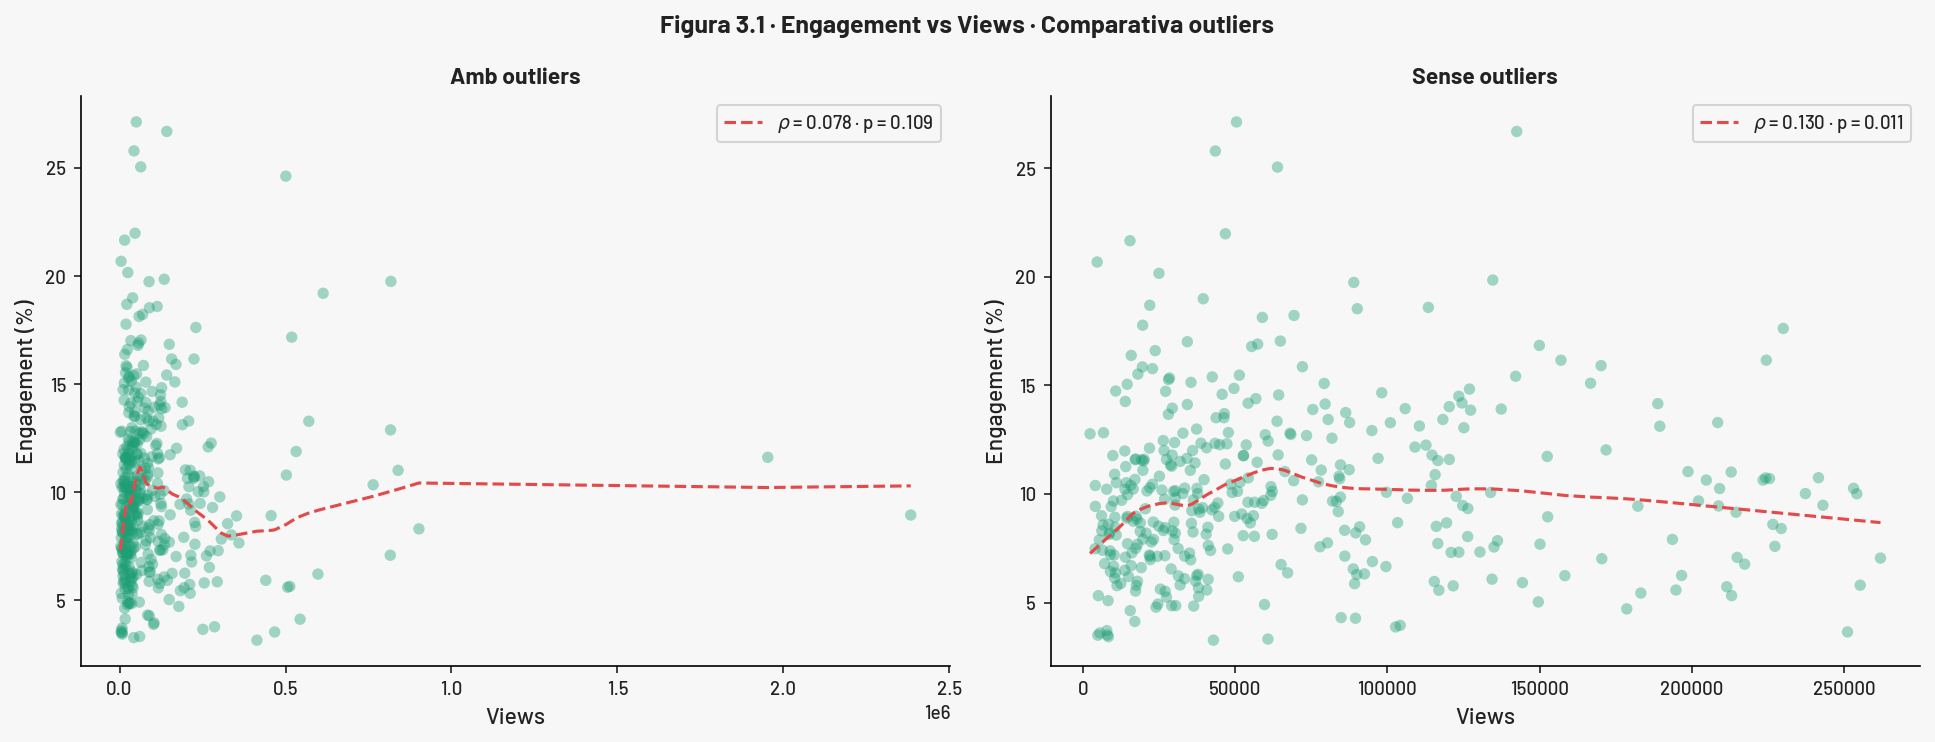


ρ amb outliers:    0.078 (p=0.109)
ρ sense outliers:  0.130 (p=0.011)


In [ ]:
# ── Spearman original (dataset complet) ──────────────────────────────────────
rho, pval = spearmanr(
    posts['Engagement'].dropna(),
    posts['Views'].dropna()
)

# ── Filtre d'outliers · Views (mètode IQR) ───────────────────────────────────
Q1 = posts['Views'].quantile(0.25)
Q3 = posts['Views'].quantile(0.75)
IQR = Q3 - Q1
llindar = Q3 + 1.5 * IQR

posts_clean = posts[posts['Views'] <= llindar].copy()

print(f"Posts totals:     {len(posts)}")
print(f"Llindar outliers: {llindar:,.0f} views")
print(f"Posts filtrats:   {len(posts_clean)} ({len(posts)-len(posts_clean)} eliminats)")

# ── Spearman dataset net ──────────────────────────────────────────────────────
rho_clean, pval_clean = spearmanr(
    posts_clean['Engagement'].dropna(),
    posts_clean['Views'].dropna()
)

# ── Scatterplot comparatiu ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, titol, rho_val, pval_val in [
    (axes[0], posts,       'Amb outliers',   rho,       pval),
    (axes[1], posts_clean, 'Sense outliers', rho_clean, pval_clean),
]:
    ax.scatter(df['Views'], df['Engagement'],
               alpha=0.4, color='#1D9E75', edgecolors='none', s=30)

    # LOWESS en lloc de OLS
    df_pair = df[['Views', 'Engagement']].dropna().sort_values('Views')
    smoothed = lowess(df_pair['Engagement'], df_pair['Views'], frac=0.3)

    ax.plot(smoothed[:, 0], smoothed[:, 1],
            color='#E24B4A', lw=1.5, ls='--',
            label=f'$\\rho$ = {rho_val:.3f} · p = {pval_val:.3f}')
    ax.set_title(titol, fontsize=11, fontweight='bold')
    ax.set_xlabel('Views')
    ax.set_ylabel('Engagement (%)')
    ax.legend(fontsize=9)

fig.suptitle('Figura 3.1 · Engagement vs Views · Comparativa outliers',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_1_scatter_engagement_views.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nρ amb outliers:    {rho:.3f} (p={pval:.3f})")
print(f"ρ sense outliers:  {rho_clean:.3f} (p={pval_clean:.3f})")

Les views i l'engagement no estan correlacionats de manera rellevant. Quan treiem els outliers, apareix una correlació estadísticament significativa però molt feble — ρ = 0.13. Això ens diu que les views no expliquen l'engagement, i que el factor diferencial d'Overtake.GP ha d'estar en una altra variable.

### Relació entre les dimensions

### Pairplot · Relació entre mètriques

Matriu de dispersió que mostra la relació entre totes les mètriques de rendiment dels posts (likes, comentaris, compartits, guardats, views, engagement). Permet identificar correlacions i patrons visuals entre dimensions.


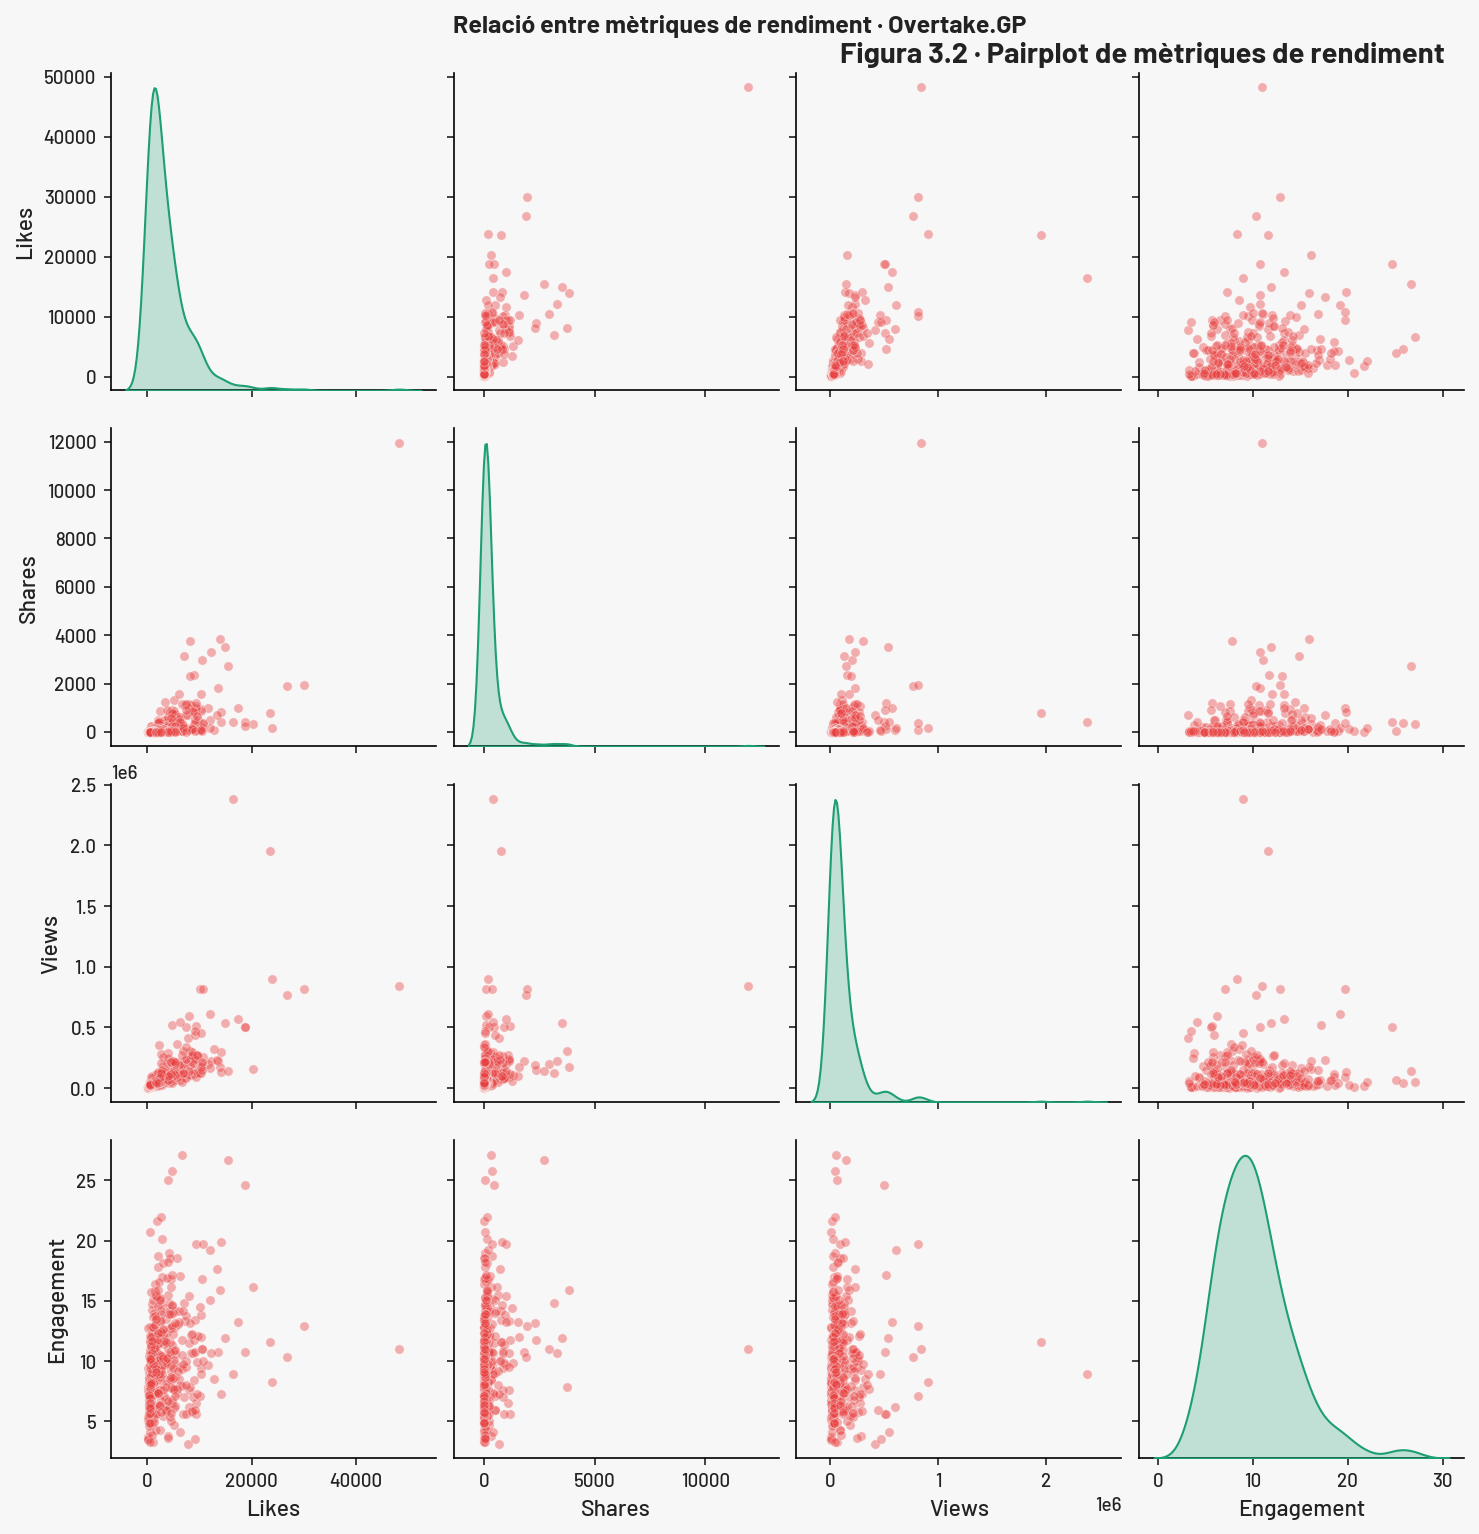

In [126]:
# Seleccionem les variables més rellevants
# Excloem Comments i Saved perquè correlacionen molt amb Likes
# i no afegeixen informació nova
vars_plot = ['Likes', 'Shares', 'Views', 'Engagement']

fig = sns.pairplot(
    posts[vars_plot].dropna(),
    diag_kind='kde',      # diagonal: distribució de cada variable
    plot_kws=dict(alpha=0.4, s=20, color='#E84040'),
    diag_kws=dict(color='#1D9E75')
)

fig.figure.suptitle(
    'Relació entre mètriques de rendiment · Overtake.GP',
    y=1.02, fontsize=12, fontweight='bold'
)

plt.title('Figura 3.2 · Pairplot de mètriques de rendiment', x= 0.01 , y=4.35)
plt.savefig('fig3_2_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusions · Bloc 3

Tot i que les dades disponibles tenen limitacions intrínseques 
(periode d'un any, concentració de posts en franja de tarda), 
podem derivar les següents tendències:

- **Format:** el dos formats estudiats obtenen un engagement similar (9.62% vs 9.72%, p=0.134), tot i que el resultat 
  s'ha d'interpretar amb cautela per la mostra reduïda.

- **Dia:** tendència no significativa estadísticament, però 
  coherent amb el calendari esportiu — diumenge i dijous lideren.

- **Hora:** cap evidència d'impacte de la franja horària, 
  condicionat per la distribució geogràfica global de l'audiència.

- **Contingut:** els posts d'opinió i comparatives maximitzen 
  l'engagement; les notícies d'impacte maximitzen el reach.

- **Engagement vs Viralitat:** són dimensions independents — 
  correlació Engagement vs Views (ρ=0.078, p=0.109 i p=0.130 , p=0.011 sense outliers). 
  Cal gestionar-les amb estratègies diferenciades.


## Extensió de l'anàlisi · Tècniques avançades

L'anàlisi anterior s'ha centrat en variables estructurals del post 
(format, dia, hora). Per aprofundir en el **contingut** — tant textual 
com visual — s'han aplicat dues tècniques d'intel·ligència artificial:

- **Bloc 3.5 · NER** (Named Entity Recognition): analitza els captions 
  per identificar quines entitats (pilots, circuits, equips) apareixen 
  i com impacten en el rendiment.

- **Bloc 3.6 · CLIP** (Contrastive Language-Image Pretraining): 
  classifica les imatges dels posts en categories visuals per detectar 
  patrons entre el tipus d'imatge i el rendiment.

Aquestes dues aproximacions són complementàries — el NER treballa 
sobre el text i el CLIP sobre la imatge del mateix post.

### Variables compartides · Blocs 3.5 i 3.6

Definim el diccionari de mètriques que s'utilitza als dos sub-blocs d'anàlisi avançada.

In [127]:
metriques = ['Engagement', 'Likes', 'Reach (Organic)']

---
### Bloc 3.5 · NER sobre captions

**Named Entity Recognition (NER)** és una tècnica de Processament del Llenguatge Natural (NLP) que identifica i classifica entitats nomenades en text.

Model: `dslim/bert-base-NER` (Hugging Face) — reconeix 4 tipus d'entitats:
- `PER` → persones (pilots, directius)
- `LOC` → llocs (circuits, països)
- `ORG` → organitzacions (equips, federacions)
- `MISC` → miscel·lània (competicions, marques)

**Objectiu:** identificar quines entitats apareixen als captions i analitzar si el tipus d'entitat impacta en el rendiment dels posts.


### Càrrega del model NER

Es carrega el model `dslim/bert-base-NER` de Hugging Face. La primera execució descarrega el model (~400MB); les següents són instantànies gràcies a la caché local.

El missatge `UNEXPECTED` sobre `bert.pooler.dense` és normal i pot ignorar-se: aquesta capa no s'utilitza en tasques de NER.


In [128]:
# ── Bloc 3.5 · NER sobre captions ───────────────────────────────────────────
# Objectiu: identificar quines entitats (pilots, circuits, equips) apareixen
# a cada post i analitzar si el tipus d'entitat impacta en el rendiment.
#
# Model: dslim/bert-base-NER (Hugging Face)
# Reconeix 4 tipus d'entitats en text anglès:
#   PER  → persones  (pilots, directius)
#   LOC  → llocs     (circuits, països)
#   ORG  → organitzacions (equips, federacions)
#   MISC → miscel·lània   (competicions, marques)

# ── 1. Carreguem el model ────────────────────────────────────────────────────
# Primera execució: descarrega ~400MB. Les següents són instantànies.
print("Carregant model NER...")
ner = pipeline(
    task="ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="first",  # agrupa tokens del mateix mot
                                    # ex: "Marc" + "Márquez" → 1 entitat
    device=-1                       # -1 = CPU. GPU NVIDIA: device=0
)
print("Model carregat correctament")

Carregant model NER...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5814.91it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model carregat correctament


In [129]:
# ── Test ràpid NER ────────────────────────────────────────────────────────
test = ner("Marc Márquez wins at Jerez ahead of Pecco Bagnaia")
for e in test:
    print(f"  {e['word']:20s} → {e['entity_group']}  ({e['score']:.2f})")

  Marc Márquez         → PER  (1.00)
  Jerez                → LOC  (1.00)
  Pecco                → ORG  (0.88)
  Bagnaia              → PER  (0.58)


In [130]:
# ── 2. Apliquem el NER a tots els captions ──────────────────────────────────

def extreure_entitats(text):
    """
    Rep el caption d'un post i retorna una llista d'entitats detectades.
    Cada entitat és un dict amb: word, entity_group, score.
    Retorna llista buida si el text és buit o invàlid.
    """
    if not isinstance(text, str) or text.strip() == "":
        return []
    try:
        return ner(text[:512])  # BERT té límit de 512 tokens
    except Exception:
        return []

print("Aplicant NER als captions...")
posts['entitats'] = posts['Content'].progress_apply(extreure_entitats)
print(f"NER completat · {len(posts)} posts processats")

Aplicant NER als captions...


100%|██████████| 419/419 [00:34<00:00, 12.31it/s]

NER completat · 419 posts processats


### Classificació per categoria dominant

Cada post s'assigna a una única categoria segons les entitats detectades, seguint un ordre de prioritat: `pilot` > `circuit` > `equip` > `competicio` > `sense_entitat`. Aquesta jerarquia reflecteix la rellevància editorial de cada tipus d'entitat en el context del motorsport.


In [131]:
# ── 3. Categoria dominant per post ──────────────────────────────────────────
# Assignem una única etiqueta per post seguint ordre de prioritat:
# pilot > circuit > equip > competicio > sense_entitat
#
# Per què aquesta prioritat? Els pilots són l'element més identificable
# del motorsport i solen ser el principal motor d'engagement.

def categoria_dominant(entitats):
    tipus = [e['entity_group'] for e in entitats]
    if 'PER'  in tipus: return 'pilot'
    if 'LOC'  in tipus: return 'circuit'
    if 'ORG'  in tipus: return 'equip'
    if 'MISC' in tipus: return 'competicio'
    return 'sense_entitat'

posts['categoria_ner'] = posts['entitats'].apply(categoria_dominant)
print(posts['categoria_ner'].value_counts())

categoria_ner
pilot            273
equip             46
sense_entitat     38
competicio        32
circuit           30
Name: count, dtype: int64


### Figura 3.3 · Rendiment per categoria d'entitat

S'analitzen tres dimensions del rendiment per cada categoria NER: engagement (%), likes i reach orgànic. Mostrar les tres mètriques permet distingir entre qualitat d'interacció i volum/viralitat, que hem identificat com a dimensions independents (ρ=0.047).


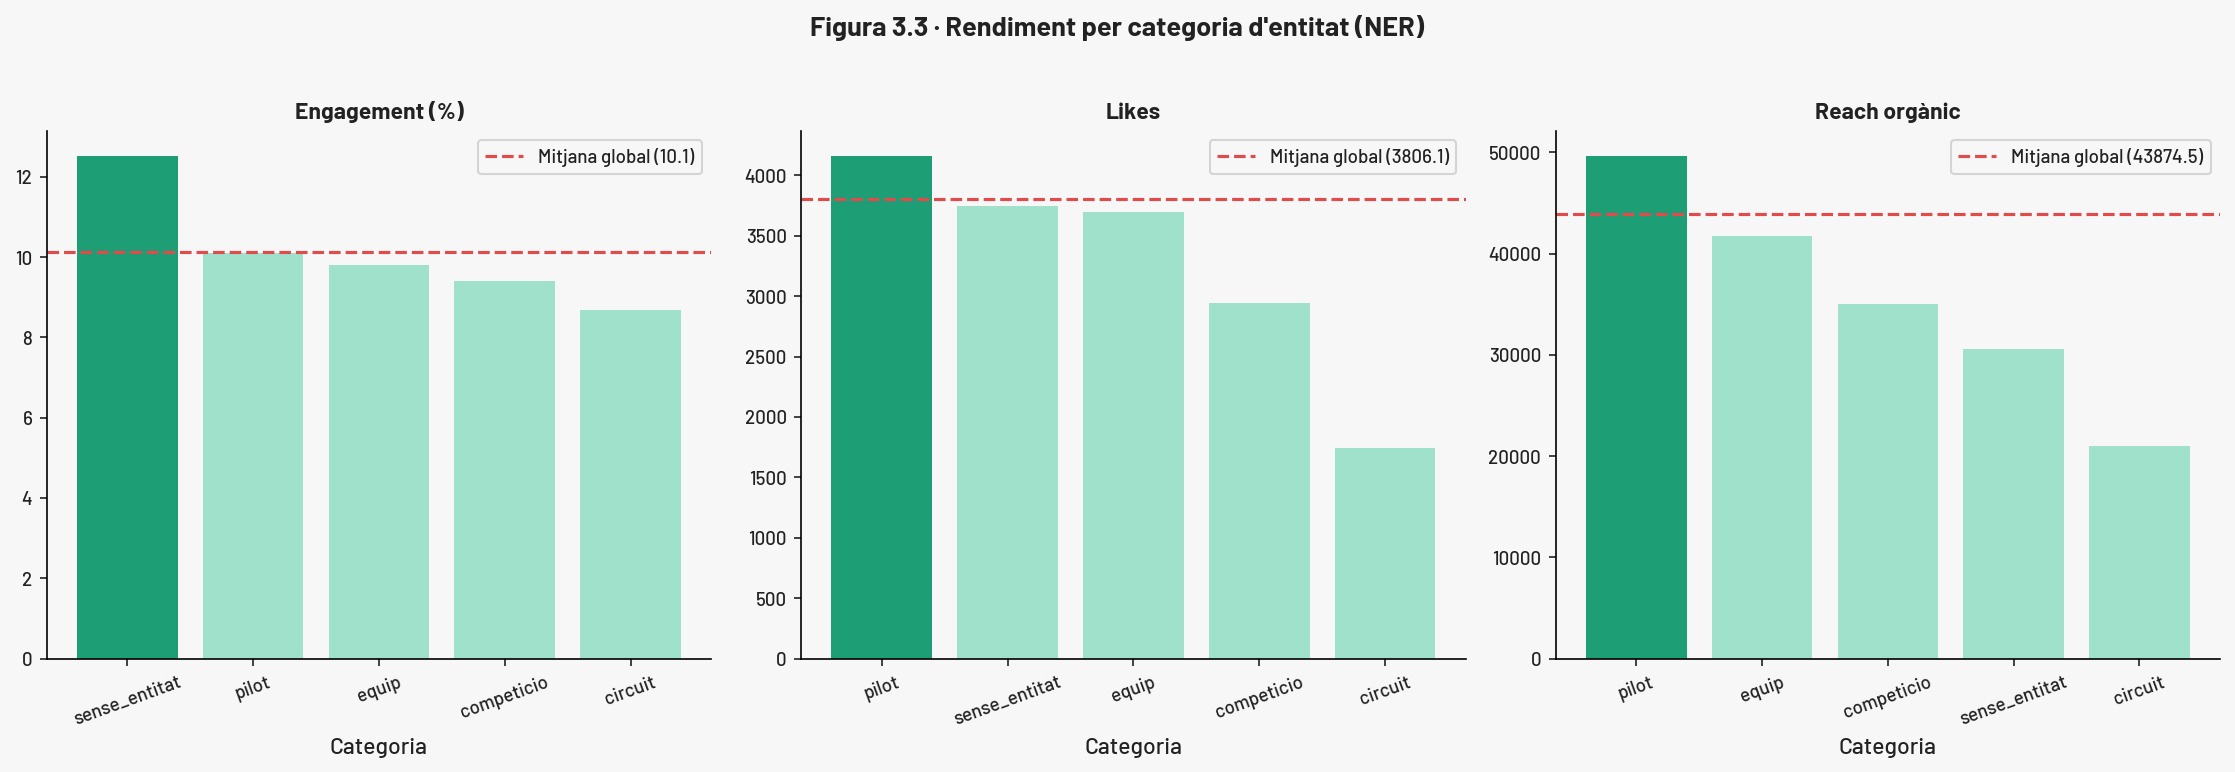

In [132]:
# ── 4. Anàlisi: tres mètriques per categoria NER ────────────────────────────
# Analitzem Engagement, Likes i Reach per separat perquè mesuren
# dimensions diferents del rendiment d'un post:
#   Engagement → qualitat de la interacció amb l'audiència existent
#   Likes      → aprovació immediata (interacció de menor cost)
#   Reach      → viralitat, difusió més enllà dels seguidors

METRIQUES = {
    'Engagement': 'Engagement (%)',
    'Likes':      'Likes',
    'Reach (Organic)': 'Reach orgànic'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, titol) in zip(axes, METRIQUES.items()):
    resum = (
        posts.groupby('categoria_ner')[col]
        .mean()
        .sort_values(ascending=False)
    )
    colors = ['#1D9E75' if i == 0 else '#9FE1CB' for i in range(len(resum))]
    ax.bar(resum.index, resum.values, color=colors)
    ax.axhline(posts[col].mean(), color='#E24B4A', lw=1.5, ls='--',
               label=f'Mitjana global ({posts[col].mean():.1f})')
    ax.set_title(titol, fontsize=11, fontweight='bold')
    ax.set_xlabel('Categoria')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=9)

fig.suptitle("Figura 3.3 · Rendiment per categoria d'entitat (NER)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_3_ner_metriques.png', dpi=150, bbox_inches='tight')
plt.show()

In [133]:
# ── 5. Taula resum ───────────────────────────────────────────────────────────
resum_ner = (
    posts.groupby('categoria_ner')[list(METRIQUES.keys())]
    .agg(['mean', 'median', 'count'])
    .round(2)
)
resum_ner.columns = ['_'.join(c) for c in resum_ner.columns]
print(resum_ner.sort_values('Engagement_mean', ascending=False))

               Engagement_mean  Engagement_median  Engagement_count  \
categoria_ner                                                         
sense_entitat            12.51              12.06                38   
pilot                    10.11               9.70               273   
equip                     9.81               9.63                46   
competicio                9.40               8.93                32   
circuit                   8.67               8.32                30   

               Likes_mean  Likes_median  Likes_count  Reach (Organic)_mean  \
categoria_ner                                                                
sense_entitat     3748.82        2449.0           38              30546.61   
pilot             4159.43        2648.0          273              49640.03   
equip             3698.65        1719.5           46              41756.72   
competicio        2946.47        1118.5           32              35013.41   
circuit           1745.63         

#### Núvol de paraules · Entitats NER

Visualització de les entitats més freqüents als captions. S'utilitza la versió basada en entitats NER (no el text complet) perquè aporta informació específica sobre pilots, circuits i competicions, eliminant paraules genèriques com *motorcycle* o *racing*.


### Figura 3.4 · Núvol de paraules · Entitats NER

Es visualitzen les entitats més freqüents als captions, filtrades per tipus `PER`, `LOC`, `ORG` i `MISC`. S'usa la versió basada en entitats NER (no el text complet) perquè elimina paraules genèriques com *motorcycle* o *racing* i revela els noms propis que dominen el contingut editorial.


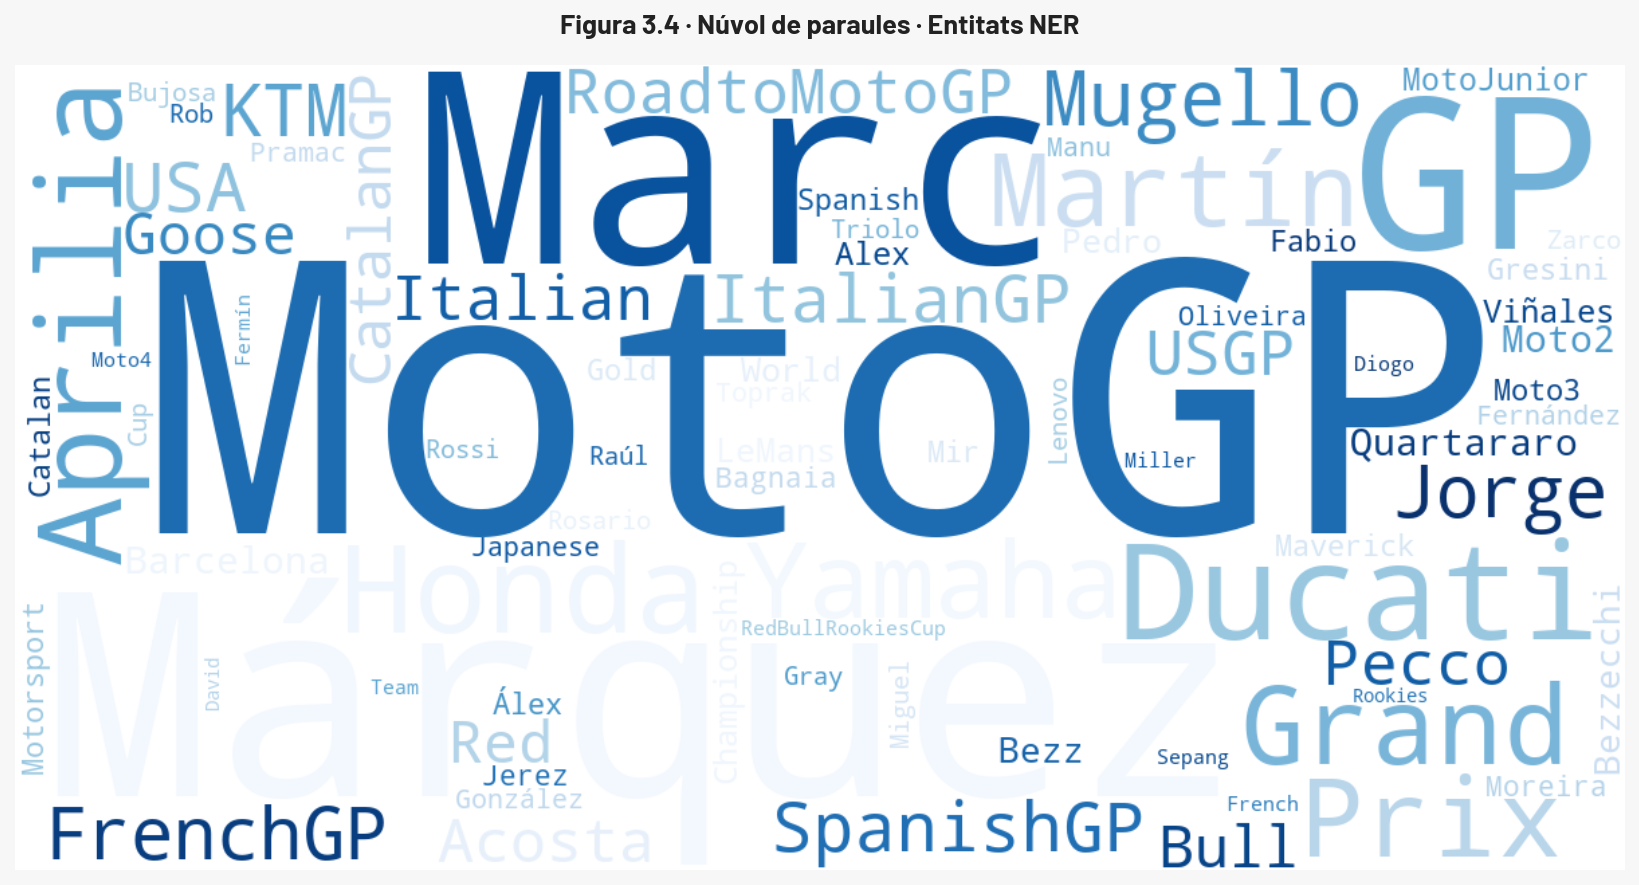

In [134]:
# ── Bloc 3.5 · Núvol de paraules · Versió 2: entitats NER ───────────────────
# Mostra només les entitats detectades pel NER (pilots, circuits, equips...).
# Més específic — revela quins noms propis dominen el contingut editorial.

# Extraiem totes les paraules de les entitats detectades
entitats_text = ' '.join([
    e['word']
    for entitats in posts['entitats']
    for e in entitats
])

wc_ner = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_words=80,
    collocations=False
).generate(entitats_text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_ner, interpolation='bilinear')
ax.axis('off')
ax.set_title('Figura 3.4 · Núvol de paraules · Entitats NER',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig3_4_wordcloud_ner.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rànquing de pilots

Anàlisi del rendiment per pilot a partir de les entitats `PER` detectades pel NER. S'aplica una funció de normalització per unificar fragments parcials (ex: `Marc` + `Márquez` → `Marc Márquez`) i gestionar casos ambigus.


### Normalització de noms de pilots

El NER fragmenta sovint els noms complets en tokens parcials (ex: `Marc` + `Márquez`) o els classifica incorrectament (ex: `Pecco` com a `ORG`). El diccionari de normalització unifica aquests fragments en el nom complet del pilot.

**Casos especials:**
- `Márquez` sense nom de pila → es classifica com `Márquez (ambigu)` quan no apareix cap dels dos germans al mateix post.
- Sobrenoms mal classificats (`Pecco`, `Bagnaia`) → capturats via detecció creuada amb el diccionari.


In [135]:
# ── Mapa de normalització ────────────────────────────────────────────────
    # Format: 'fragment' → 'nom complet'
    # Ordre important: els noms complets primer per evitar sobreescritures
normalitzacio = {
    # Márquez
    'Marc Márquez':  'Marc Márquez',
    'Álex Márquez':  'Álex Márquez',
    'Alex Márquez':  'Álex Márquez',
    'Marc':          'Marc Márquez',
    'Alex':          'Álex Márquez',
    'Álex':          'Álex Márquez',
    # Martín
    'Jorge Martín':  'Jorge Martín',
    'Martín':        'Jorge Martín',
    # Bezzecchi
    'Marco Bezzecchi': 'Marco Bezzecchi',
    'Bezzecchi':     'Marco Bezzecchi',
    'Bezz':          'Marco Bezzecchi',
    # Acosta
    'Pedro Acosta':  'Pedro Acosta',
    'Acosta':        'Pedro Acosta',
    'Pedro':         'Pedro Acosta',
    # Mir
    'Joan Mir':      'Joan Mir',
    'Mir':           'Joan Mir',
    # Quartararo
    'Fabio Quartararo': 'Fabio Quartararo',
    'Quartararo':    'Fabio Quartararo',
    'Fabio':         'Fabio Quartararo',
    # Viñales
    'Maverick Viñales': 'Maverick Viñales',
    'Viñales':       'Maverick Viñales',
    'Maverick':      'Maverick Viñales',
    # Oliveira
    'Miguel Oliveira': 'Miguel Oliveira',
    'Oliveira':      'Miguel Oliveira',
    'Miguel':        'Miguel Oliveira',
    # Zarco
    'Johann Zarco':  'Johann Zarco',
    'Zarco':         'Johann Zarco',
    # Aldeguer
    'Fermín Aldeguer': 'Fermín Aldeguer',
    'Fermín':        'Fermín Aldeguer',
    # Marini
    'Luca Marini':   'Luca Marini',
    'Marini':        'Luca Marini',
    # Miller
    'Jack Miller':   'Jack Miller',
    'Miller':        'Jack Miller',
    # Lorenzo
    'Jorge Lorenzo': 'Jorge Lorenzo',
    'Lorenzo':       'Jorge Lorenzo',
    # Rossi
    'Valentino Rossi': 'Valentino Rossi',
    'Rossi':           'Valentino Rossi',
    # González
    'Manu González':   'Manu González',
    'Manuel González': 'Manu González',
    # Di Giannantonio
    'Fabio Di Giannantonio': 'Fabio Di Giannantonio',
    'Di Giannantonio':       'Fabio Di Giannantonio',
    'Diggia':                'Fabio Di Giannantonio',
    # Pecco Bagnaia
    'Pecco':         'Pecco Bagnaia',
    'Bagnaia':       'Pecco Bagnaia',
    'Pecco Bagnaia':       'Pecco Bagnaia',
    'Francesco Bagnaia':       'Pecco Bagnaia',
    'Francesco':       'Pecco Bagnaia',
    # Fragments residuals
    'Jorge':       'Jorge Martín',
    'Martinator':  'Jorge Martín',
    'Raúl':        'Raúl Fernández',
    'Stoner': 'Casey Stoner',
}


In [136]:
# Conjunt de tots els noms del diccionari de normalització

def extreure_pilots(entitats):
    """
    Extreu entitats PER del NER.
    També captura entitats ORG/MISC que coincideixen amb noms
    coneguts del diccionari de normalització de pilots.
    """
    pilots = [e['word'] for e in entitats if e['entity_group'] == 'PER']
    mal_classificats = [
        e['word'] for e in entitats
        if e['entity_group'] in ('ORG', 'MISC')
        and e['word'] in normalitzacio
    ]
    return pilots + mal_classificats

posts['pilots'] = posts['entitats'].apply(extreure_pilots)

In [137]:
def netejar_pilots(llista_pilots):
    """
    Neteja i normalitza la llista de pilots detectats pel NER en un post.
    
    Operacions:
        1. Unifica fragments parcials amb el nom complet del pilot.
        2. Gestiona el cas ambigu de 'Márquez' sense nom de pila.
        3. Elimina entitats que no són pilots (periodistes, fonts).
        4. Elimina duplicats.
    
    Args:
        llista_pilots (list): llista de strings amb noms detectats com a PER pel NER.
    
    Returns:
        list: llista neta i sense duplicats.
    
    Limitació:
        'Márquez (ambigu)' pot fer referència a Marc o Àlex Márquez segons context.
    """
    
    # ── No pilots a eliminar ─────────────────────────────────────────────────
    no_pilots = {'Rob Gray', 'Rosario Triolo', 'Goose', 'Gresini','Mugello'}

    # ── Aplicar normalització ────────────────────────────────────────────────
    resultat = [normalitzacio.get(p, p) for p in llista_pilots]

    # ── Gestió de Márquez ambigu ─────────────────────────────────────────────
    if 'Márquez' in resultat:
        if 'Marc Márquez' not in resultat and 'Álex Márquez' not in resultat:
            resultat[resultat.index('Márquez')] = 'Márquez (ambigu)'
        else:
            resultat.remove('Márquez')

    # ── Eliminar no pilots ───────────────────────────────────────────────────
    resultat = [p for p in resultat if p not in no_pilots]

    # ── Eliminar duplicats ───────────────────────────────────────────────────
    return list(set(resultat))
    

In [138]:
posts['pilots_nets'] = posts['pilots'].apply(netejar_pilots)
ranking_nets = posts['pilots_nets'].explode().value_counts()
print(ranking_nets.head(25))

pilots_nets
Marc Márquez             71
Jorge Martín             28
Marco Bezzecchi          26
Pecco Bagnaia            25
Pedro Acosta             22
Álex Márquez             21
Fabio Quartararo         18
Maverick Viñales         17
Márquez (ambigu)         11
Joan Mir                  8
Miguel Oliveira           8
Valentino Rossi           7
Johann Zarco              7
Fabio Di Giannantonio     6
Jack Miller               6
Raúl Fernández            6
Fermín Aldeguer           6
Jorge Lorenzo             5
Luca Marini               5
Diogo Moreira             5
Manu González             5
Bujosa                    4
Casey Stoner              4
Bastianini                4
Borg                      3
Name: count, dtype: int64


In [139]:
df_pilots = posts.explode('pilots_nets')
ranking_metriques = df_pilots.groupby('pilots_nets').agg(
    n_posts     = ('Likes', 'count'),
    likes_mean  = ('Likes', 'mean'),
    eng_mean    = ('Engagement', 'mean'),
    views_mean  = ('Views', 'mean'),
    reach_mean  = ('Reach (Organic)', 'mean')
).round(2)

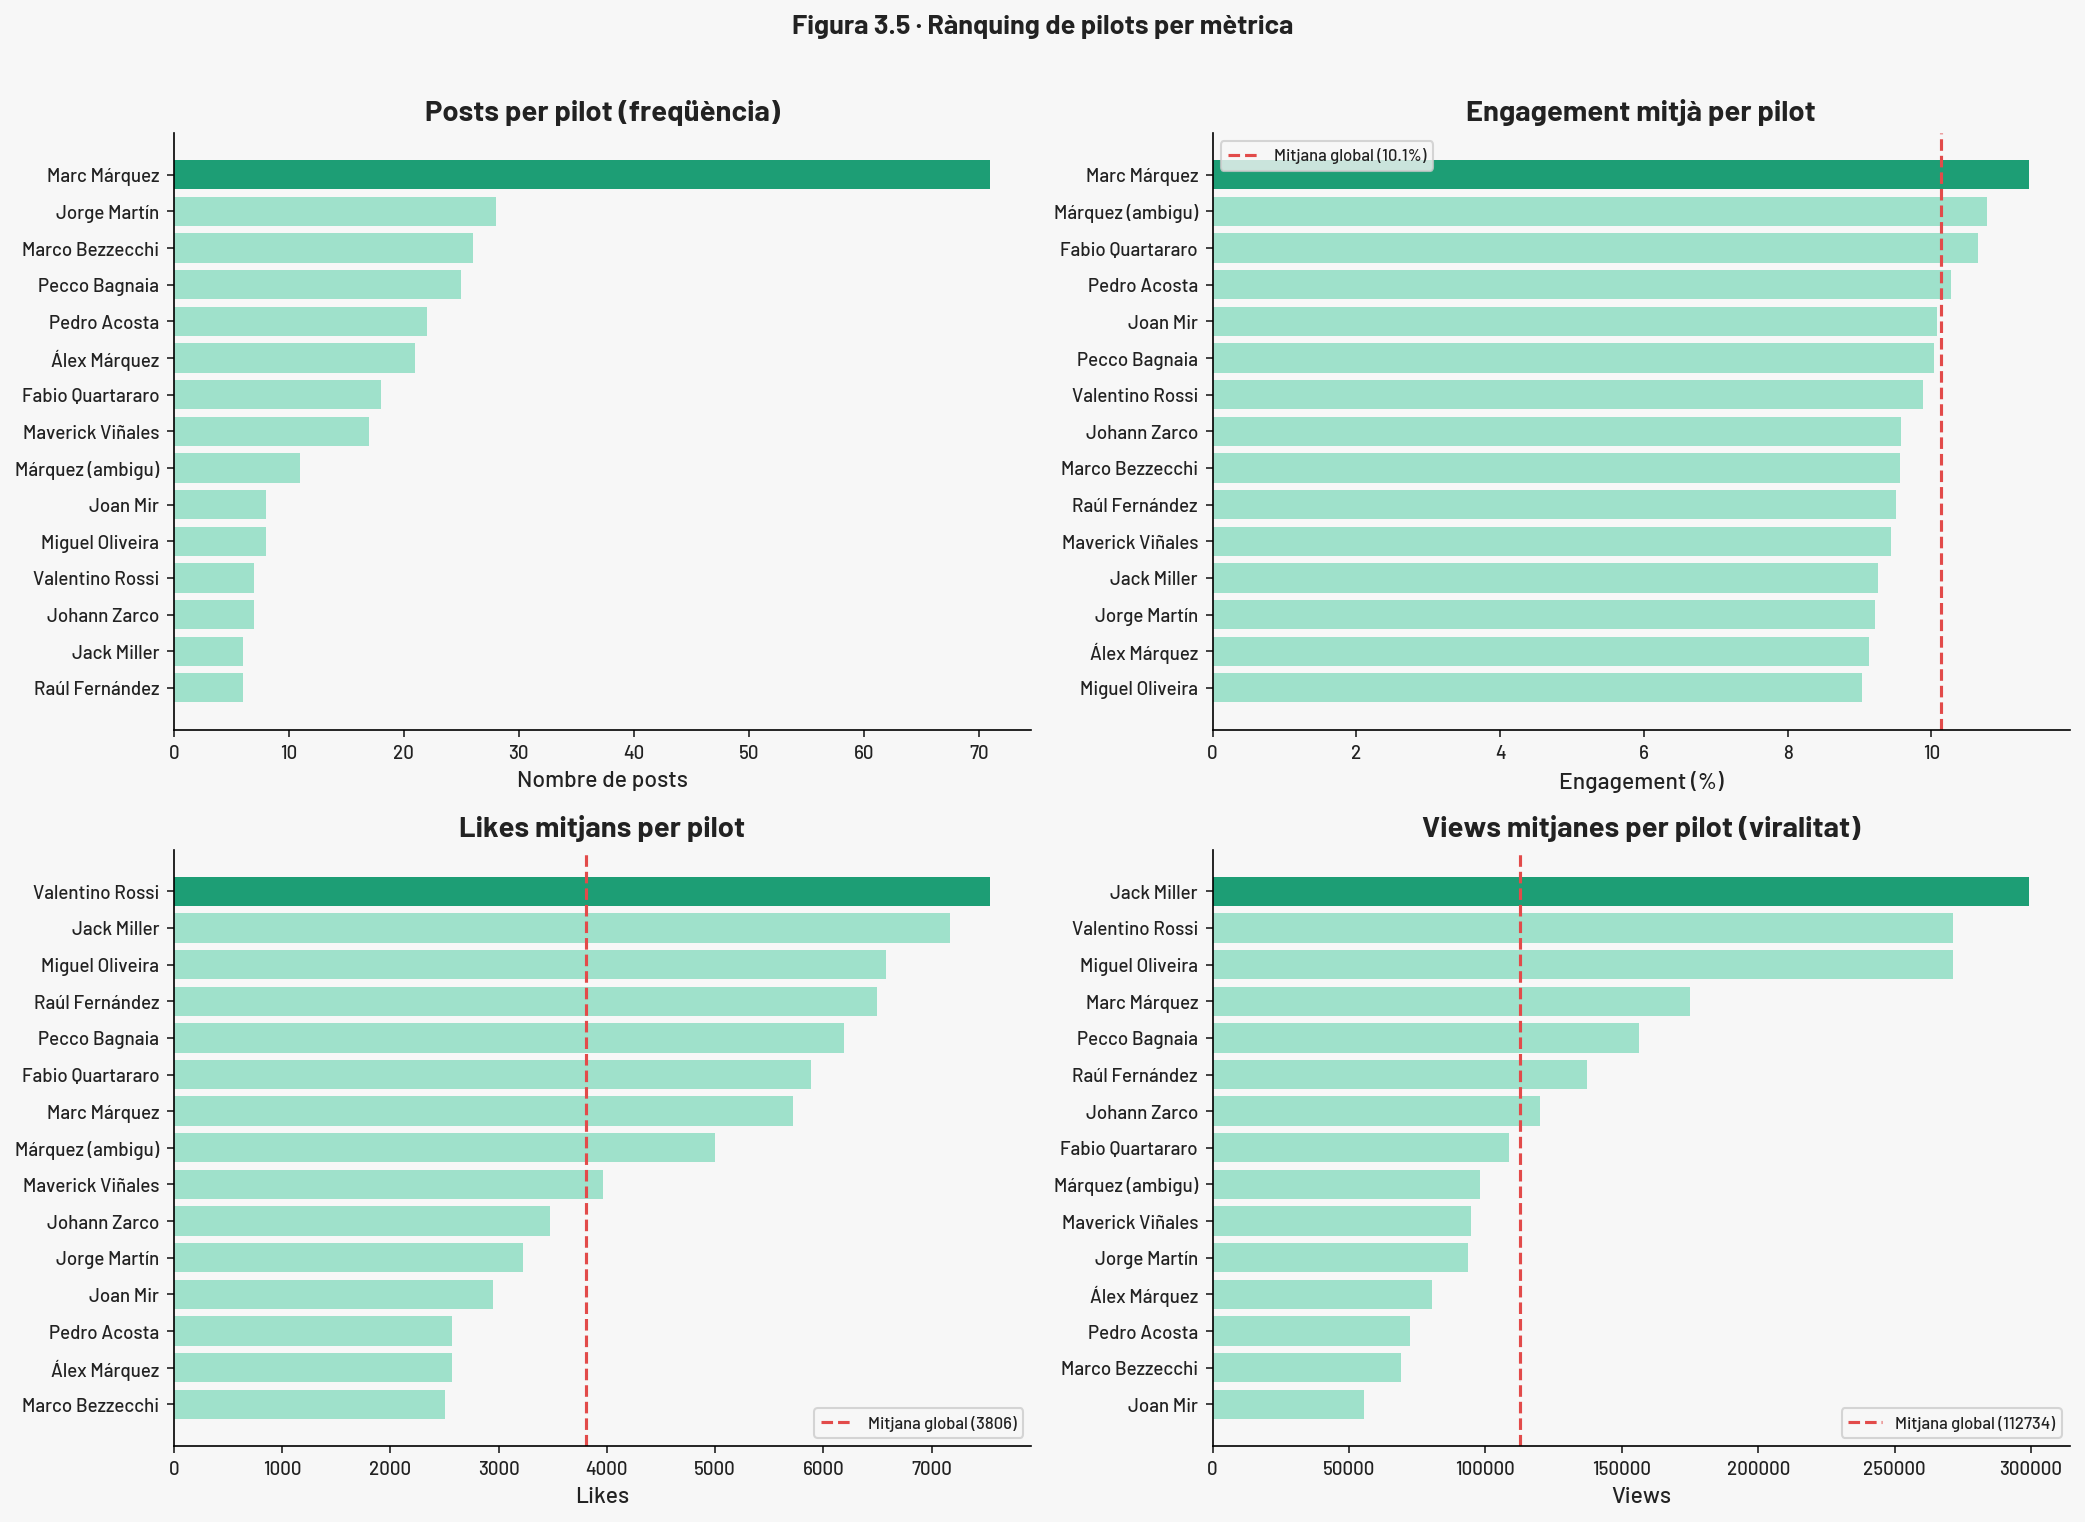

In [140]:
# ── Rànquing de pilots · Gràfics ─────────────────────────────────────────────
TOP_N = 15
MIN_POSTS = 5

ranking_filtrat = (
    ranking_metriques[ranking_metriques['n_posts'] >= MIN_POSTS]
    .sort_values('n_posts', ascending=False)
    .head(TOP_N)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Freqüència ───────────────────────────────────────────────────────────────
ax = axes[0, 0]
data = ranking_filtrat.sort_values('n_posts', ascending=True)
colors = ['#1D9E75' if i == len(data)-1 else '#9FE1CB' for i in range(len(data))]
ax.barh(data.index, data['n_posts'], color=colors)
ax.set_title('Posts per pilot (freqüència)', fontweight='bold')
ax.set_xlabel('Nombre de posts')

# ── Engagement mitjà ─────────────────────────────────────────────────────────
ax = axes[0, 1]
data = ranking_filtrat.sort_values('eng_mean', ascending=True)
colors = ['#1D9E75' if i == len(data)-1 else '#9FE1CB' for i in range(len(data))]
ax.barh(data.index, data['eng_mean'], color=colors)
ax.axvline(posts['Engagement'].mean(), color='#E24B4A',
           lw=1.5, ls='--', label=f"Mitjana global ({posts['Engagement'].mean():.1f}%)")
ax.set_title('Engagement mitjà per pilot', fontweight='bold')
ax.set_xlabel('Engagement (%)')
ax.legend(fontsize=8)

# ── Likes mitjans ────────────────────────────────────────────────────────────
ax = axes[1, 0]
data = ranking_filtrat.sort_values('likes_mean', ascending=True)
colors = ['#1D9E75' if i == len(data)-1 else '#9FE1CB' for i in range(len(data))]
ax.barh(data.index, data['likes_mean'], color=colors)
ax.axvline(posts['Likes'].mean(), color='#E24B4A',
           lw=1.5, ls='--', label=f"Mitjana global ({posts['Likes'].mean():.0f})")
ax.set_title('Likes mitjans per pilot', fontweight='bold')
ax.set_xlabel('Likes')
ax.legend(fontsize=8)

# ── Viralitat (Views) ────────────────────────────────────────────────────────
ax = axes[1, 1]
data = ranking_filtrat.sort_values('views_mean', ascending=True)
colors = ['#1D9E75' if i == len(data)-1 else '#9FE1CB' for i in range(len(data))]
ax.barh(data.index, data['views_mean'], color=colors)
ax.axvline(posts['Views'].mean(), color='#E24B4A',
           lw=1.5, ls='--', label=f"Mitjana global ({posts['Views'].mean():.0f})")
ax.set_title('Views mitjanes per pilot (viralitat)', fontweight='bold')
ax.set_xlabel('Views')
ax.legend(fontsize=8)

fig.suptitle('Figura 3.5 · Rànquing de pilots per mètrica',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_5_ranking_pilots.png', dpi=150, bbox_inches='tight')
plt.show()

#### Índex de rellevància composit

Normalització min-max de les quatre mètriques (freqüència, engagement, likes, views) per construir un índex compost. S'aplica ponderació per arrel quadrada de la freqüència per evitar que pilots amb pocs posts però alta viralitat puntual dominin el rànquing.

In [141]:
# normalitzar valors: valor_normalitzat = (valor - mínim) / (màxim - mínim)
for col in ['n_posts', 'likes_mean', 'eng_mean', 'views_mean']:
    ranking_filtrat[col + '_norm'] = (ranking_filtrat[col] - ranking_filtrat[col].min()) / (ranking_filtrat[col].max() - ranking_filtrat[col].min())

In [142]:
ranking_filtrat['index_rellevancia'] = ranking_filtrat[
    ['n_posts_norm', 'likes_mean_norm', 'eng_mean_norm', 'views_mean_norm']
].mean(axis=1).round(3)

print(ranking_filtrat[['index_rellevancia']].sort_values('index_rellevancia', ascending=False))

                  index_rellevancia
pilots_nets                        
Marc Márquez                  0.782
Valentino Rossi               0.566
Jack Miller                   0.506
Pecco Bagnaia                 0.467
Fabio Quartararo              0.442
Miguel Oliveira               0.431
Márquez (ambigu)              0.374
Raúl Fernández                0.333
Pedro Acosta                  0.215
Maverick Viñales              0.199
Jorge Martín                  0.179
Johann Zarco                  0.177
Marco Bezzecchi               0.148
Joan Mir                      0.142
Álex Márquez                  0.097


In [143]:
ranking_filtrat['index_ponderat'] = (
    ranking_filtrat['index_rellevancia'] * ranking_filtrat['n_posts_norm']
).round(3)

print(ranking_filtrat[['index_rellevancia', 'index_ponderat', 'n_posts']]
      .sort_values('index_ponderat', ascending=False))

                  index_rellevancia  index_ponderat  n_posts
pilots_nets                                                 
Marc Márquez                  0.782           0.782       71
Pecco Bagnaia                 0.467           0.137       25
Fabio Quartararo              0.442           0.082       18
Jorge Martín                  0.179           0.061       28
Pedro Acosta                  0.215           0.053       22
Marco Bezzecchi               0.148           0.046       26
Maverick Viñales              0.199           0.034       17
Márquez (ambigu)              0.374           0.029       11
Álex Márquez                  0.097           0.022       21
Miguel Oliveira               0.431           0.013        8
Valentino Rossi               0.566           0.009        7
Joan Mir                      0.142           0.004        8
Johann Zarco                  0.177           0.003        7
Raúl Fernández                0.333           0.000        6
Jack Miller             

In [144]:
ranking_filtrat['index_ponderat_v2'] = (
    ranking_filtrat['index_rellevancia'] * ranking_filtrat['n_posts_norm'].pow(0.5)
).round(3)

print(ranking_filtrat[['index_rellevancia', 'index_ponderat', 'index_ponderat_v2', 'n_posts']]
      .sort_values('index_ponderat_v2', ascending=False))

                  index_rellevancia  index_ponderat  index_ponderat_v2  \
pilots_nets                                                              
Marc Márquez                  0.782           0.782              0.782   
Pecco Bagnaia                 0.467           0.137              0.252   
Fabio Quartararo              0.442           0.082              0.190   
Pedro Acosta                  0.215           0.053              0.107   
Jorge Martín                  0.179           0.061              0.104   
Márquez (ambigu)              0.374           0.029              0.104   
Marco Bezzecchi               0.148           0.046              0.082   
Maverick Viñales              0.199           0.034              0.082   
Miguel Oliveira               0.431           0.013              0.076   
Valentino Rossi               0.566           0.009              0.070   
Álex Márquez                  0.097           0.022              0.047   
Joan Mir                      0.142   

In [145]:
print(ranking_nets.head(20))
print()
print(ranking_metriques.loc['Pecco Bagnaia'])
print()
print(ranking_filtrat.sort_values('index_ponderat_v2', ascending=False).head(16)[['index_ponderat_v2', 'n_posts']])

pilots_nets
Marc Márquez             71
Jorge Martín             28
Marco Bezzecchi          26
Pecco Bagnaia            25
Pedro Acosta             22
Álex Márquez             21
Fabio Quartararo         18
Maverick Viñales         17
Márquez (ambigu)         11
Joan Mir                  8
Miguel Oliveira           8
Valentino Rossi           7
Johann Zarco              7
Fabio Di Giannantonio     6
Jack Miller               6
Raúl Fernández            6
Fermín Aldeguer           6
Jorge Lorenzo             5
Luca Marini               5
Diogo Moreira             5
Name: count, dtype: int64

n_posts           25.00
likes_mean      6189.92
eng_mean          10.03
views_mean    156125.44
reach_mean     81308.60
Name: Pecco Bagnaia, dtype: float64

                  index_ponderat_v2  n_posts
pilots_nets                                 
Marc Márquez                  0.782       71
Pecco Bagnaia                 0.252       25
Fabio Quartararo              0.190       18
Pedro Acosta       

#### Graella de rellevància · Visualització interactiva

Visualització en format de graella de sortida de MotoGP. Amb tooltips interactius amb les mètriques de cada pilot.

In [146]:
# ── Bloc 3.5 · Graella de rellevància · Pilots ──────────────────────────────


# Generem les dades dels pilots des del dataframe
pilots_data = (
    ranking_filtrat
    .sort_values('index_ponderat_v2', ascending=False)
    .head(15)
    .reset_index()
)[['pilots_nets', 'n_posts', 'likes_mean', 'eng_mean', 'views_mean', 'index_ponderat_v2']]

# Construïm el JSON de pilots per injectar al HTML
pilots_list = []
for i, row in enumerate(pilots_data.itertuples(), 1):
    pilots_list.append({
        "pos":   i,
        "name":  row.pilots_nets,
        "idx":   round(row.index_ponderat_v2, 3),
        "posts": int(row.n_posts),
        "likes": int(row.likes_mean),
        "eng":   round(row.eng_mean, 2),
        "views": int(row.views_mean)
    })

pilots_json = json.dumps(pilots_list)

html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=Exo+2:wght@400;600;700;900&family=Rajdhani:wght@400;600;700&display=swap');
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ background: #0d1a0d; font-family: 'Exo 2', sans-serif; min-height: 100vh; display: flex; flex-direction: column; align-items: center; padding: 24px 0; }}
  h1 {{ font-family: 'Rajdhani', sans-serif; font-size: 22px; font-weight: 700; color: #fff; letter-spacing: 0.12em; text-transform: uppercase; margin-bottom: 4px; text-align: center; }}
  .subtitle {{ font-size: 10px; color: #556655; letter-spacing: 0.2em; text-transform: uppercase; margin-bottom: 24px; text-align: center; }}
  .circuit-outer {{ width: 100%; display: flex; align-items: stretch; }}
  .grass {{ flex: 0 0 32px; background: repeating-linear-gradient(180deg, #1a3d1a 0px, #1a3d1a 8px, #1f4a1f 8px, #1f4a1f 16px); position: relative; }}
  .grass.left {{ border-right: 3px solid #FFD700; }}
  .grass.right {{ border-left: 3px solid #FFD700; }}
  .grass.left::after, .grass.right::before {{ content: ''; position: absolute; top: 0; bottom: 0; width: 8px; background: repeating-linear-gradient(180deg, #E24B4A 0px, #E24B4A 12px, #fff 12px, #fff 24px); }}
  .grass.left::after {{ right: -11px; }}
  .grass.right::before {{ left: -11px; }}
  .track {{ flex: 1; background: linear-gradient(180deg, #1c1c1c 0%, #141414 100%); padding: 20px 20px 28px; position: relative; overflow: visible; }}
  .start-label {{ font-size: 9px; color: #E24B4A; letter-spacing: 0.3em; text-transform: uppercase; text-align: center; margin-bottom: 8px; font-weight: 600; }}
  .start-line {{ width: 100%; height: 7px; background: repeating-linear-gradient(90deg, #fff 0px, #fff 12px, #1c1c1c 12px, #1c1c1c 24px); margin-bottom: 16px; border-radius: 1px; }}
  .grid-container {{ display: flex; flex-direction: column; gap: 10px; }}
  .grid-row {{ display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 8px; }}
  .grid-slot {{ background: linear-gradient(135deg, #212121 0%, #181818 100%); border: 1px solid #2e2e2e; border-radius: 8px; padding: 10px 12px; cursor: pointer; position: relative; transition: all 0.2s ease; overflow: visible; }}
  .grid-slot::before {{ content: ''; position: absolute; top: 0; left: 0; right: 0; height: 2px; background: var(--accent); border-radius: 8px 8px 0 0; }}
  .grid-slot:hover {{ border-color: var(--accent); transform: translateY(-2px); box-shadow: 0 6px 20px rgba(0,0,0,0.5); z-index: 50; }}
  .grid-slot:hover .tooltip {{ opacity: 1; pointer-events: auto; transform: translateX(-50%) translateY(0); }}
  .pos-num {{ font-family: 'Rajdhani', sans-serif; font-size: 11px; font-weight: 700; color: var(--accent); margin-bottom: 3px; }}
  .pilot-name {{ font-size: 11.5px; font-weight: 700; color: #efefef; line-height: 1.2; margin-bottom: 5px; }}
  .index-bar-wrap {{ width: 100%; height: 3px; background: #2a2a2a; border-radius: 2px; margin-bottom: 3px; }}
  .index-bar {{ height: 100%; background: var(--accent); border-radius: 2px; opacity: 0.8; }}
  .index-val {{ font-size: 9px; color: #484848; font-family: 'Rajdhani', sans-serif; }}
  .pole-badge {{ position: absolute; top: 6px; right: 8px; font-size: 8px; font-weight: 700; color: #FFD700; }}
  .tooltip {{ position: absolute; bottom: calc(100% + 10px); left: 50%; transform: translateX(-50%) translateY(6px); background: #0a0a0a; border: 1px solid #333; border-radius: 8px; padding: 10px 13px; width: 190px; z-index: 200; opacity: 0; pointer-events: none; transition: all 0.15s ease; box-shadow: 0 8px 28px rgba(0,0,0,0.7); }}
  .tooltip::after {{ content: ''; position: absolute; top: 100%; left: 50%; transform: translateX(-50%); border: 5px solid transparent; border-top-color: #333; }}
  .tt-name {{ font-size: 12px; font-weight: 700; color: #fff; margin-bottom: 7px; padding-bottom: 6px; border-bottom: 1px solid #1e1e1e; }}
  .tt-row {{ display: flex; justify-content: space-between; font-size: 10px; margin-bottom: 3px; }}
  .tt-label {{ color: #555; }}
  .tt-value {{ color: #ccc; font-weight: 600; font-family: 'Rajdhani', sans-serif; font-size: 11px; }}
  .lights-wrap {{ display: flex; justify-content: center; gap: 10px; margin-top: 22px; }}
  .light-panel {{ background: #111; border: 1px solid #222; border-radius: 6px; padding: 5px 6px; }}
  .light {{ width: 12px; height: 12px; border-radius: 50%; background: #E24B4A; box-shadow: 0 0 10px #E24B4A; animation: blink 1.4s ease-in-out infinite; }}
  .light-panel:nth-child(2) .light {{ animation-delay: 0.28s; }}
  .light-panel:nth-child(3) .light {{ animation-delay: 0.56s; }}
  .light-panel:nth-child(4) .light {{ animation-delay: 0.84s; }}
  .light-panel:nth-child(5) .light {{ animation-delay: 1.12s; }}
  @keyframes blink {{ 0%, 100% {{ opacity: 1; }} 50% {{ opacity: 0.15; }} }}
  .finish-label {{ font-size: 9px; color: #444; letter-spacing: 0.3em; text-transform: uppercase; text-align: center; margin-top: 16px; font-weight: 600; }}
</style>
</head>
<body>
<h1>Overtake.GP · Graella de Rellevància</h1>
<p class="subtitle">Índex compost · Freqüència · Engagement · Likes · Viralitat</p>
<div class="circuit-outer">
  <div class="grass left"></div>
  <div class="track">
    <div class="start-label">▼ LÍNIA DE SORTIDA</div>
    <div class="start-line"></div>
    <div class="grid-container" id="grid"></div>
    <div class="lights-wrap" id="lights"></div>
    <div class="finish-label">▲ FINAL DE GRAELLA</div>
  </div>
  <div class="grass right"></div>
</div>
<script>
const pilots = {pilots_json};
const accents = ['#FFD700','#C0C0C0','#CD7F32','#1D9E75','#4A90D9','#E67E22','#1D9E75','#4A90D9','#E67E22','#1D9E75','#4A90D9','#E67E22','#1D9E75','#4A90D9','#E67E22'];
const rows = [[pilots[1],pilots[0],pilots[2]],[pilots[3],pilots[4],pilots[5]],[pilots[6],pilots[7],pilots[8]],[pilots[9],pilots[10],pilots[11]],[pilots[12],pilots[13],pilots[14]]];
const grid = document.getElementById('grid');
rows.forEach(row => {{
  const rowEl = document.createElement('div');
  rowEl.className = 'grid-row';
  row.forEach(p => {{
    const slot = document.createElement('div');
    slot.className = 'grid-slot';
    slot.style.setProperty('--accent', accents[p.pos-1]);
    const tt = '<div class="tooltip"><div class="tt-name">'+p.name+'</div><div class="tt-row"><span class="tt-label">Posició</span><span class="tt-value">P'+p.pos+'</span></div><div class="tt-row"><span class="tt-label">Posts</span><span class="tt-value">'+p.posts+'</span></div><div class="tt-row"><span class="tt-label">Engagement</span><span class="tt-value">'+p.eng+'%</span></div><div class="tt-row"><span class="tt-label">Likes mitjans</span><span class="tt-value">'+p.likes.toLocaleString()+'</span></div><div class="tt-row"><span class="tt-label">Views mitjanes</span><span class="tt-value">'+p.views.toLocaleString()+'</span></div><div class="tt-row"><span class="tt-label">Índex</span><span class="tt-value">'+p.idx.toFixed(3)+'</span></div></div>';
    slot.innerHTML = (p.pos===1?'<span class="pole-badge">POLE</span>':'')+
      '<div class="pos-num">P'+p.pos+'</div>'+
      '<div class="pilot-name">'+p.name+'</div>'+
      '<div class="index-bar-wrap"><div class="index-bar" style="width:'+Math.max(p.idx*100,2)+'%"></div></div>'+
      '<div class="index-val">idx '+p.idx.toFixed(3)+'</div>'+tt;
    rowEl.appendChild(slot);
  }});
  grid.appendChild(rowEl);
}});
const lw = document.getElementById('lights');
for(let i=0;i<5;i++){{const p=document.createElement('div');p.className='light-panel';const l=document.createElement('div');l.className='light';p.appendChild(l);lw.appendChild(p);}}
</script>
</body>
</html>"""

with open('overtake_graella_pilots.html', 'w', encoding='utf-8') as f:
    f.write(html)

webbrowser.open('file://' + os.path.abspath('overtake_graella_pilots.html'))

True

#### Conclusions · Bloc 3.5

**Distribució:** el 64% dels posts mencionen pilots, confirma que 
els protagonistes individuals són el nucli editorial del mitjà. 
Circuit és la categoria menys freqüent (7.6%) i la de menor 
rendiment en les tres mètriques.

**Engagement:** lidera `sense_entitat` (12.5% vs mitjana 10.2%). 
El contingut sense entitats concretes — opinions, preguntes, 
contingut emocional — genera interacció consistent i estable 
(mitjana ≈ mediana).

**Likes i Reach:** lidera `pilot` amb diferència, però amb 
distribució esbiaixada (mitjana 4.372 vs mediana 2.775 en likes). 
Uns pocs posts virals estiren la mitjana — el post típic de pilot 
rendeix menys del que suggereix la mitjana.

**Conclusió estratègica:** pilots maximitzen volum (reach i likes); 
contingut sense entitat maximitza qualitat d'interacció (engagement). 
Dimensions independents (ρ=0.047) que requereixen estratègies 
diferenciades.

---
### Bloc 3.6 · CLIP sobre imatges

**CLIP** (Contrastive Language-Image Pretraining) és un model d'OpenAI que entén imatges i text simultàniament. Permet fer *zero-shot classification*: classificar imatges en categories definides en llenguatge natural sense entrenament específic.

Model: `openai/clip-vit-base-patch32`

**Limitació de la mostra:** Instagram expira les URLs de les imatges passats uns dies. L'anàlisi cobreix 130 dels 419 posts (31%) — els posts més recents. Les 289 URLs restants retornen HTTP 403. Vegeu la cel·la de diagnòstic per als detalls.

**Categories visuals definides:**
- `podi` · `pit_lane` · `infografia` · `retrat_pilot` · `accio_pista`


### Càrrega del model CLIP

Es carrega el model `openai/clip-vit-base-patch32`. La primera execució descarrega el model (~400MB); les següents són instantànies gràcies a la caché local.

**Zero-shot classification:** el model no ha estat entrenat específicament per a MotoGP. Classifica les imatges comparant els seus embeddings visuals amb els embeddings textuals de les categories definides.


In [147]:
# ── Bloc 3.6 · CLIP sobre imatges ───────────────────────────────────────────
# Objectiu: classificar visualment cada post i analitzar si el tipus
# d'imatge impacta en el rendiment.
#
# Model: openai/clip-vit-base-patch32
# CLIP entén imatges i text alhora. Amb "zero-shot classification"
# li passem les categories en llenguatge natural i ell tria la més
# probable per cada imatge — sense entrenament específic per a MotoGP.
#
# Zero-shot vol dir: el model mai ha vist les nostres imatges,
# però entén els conceptes visuals prou bé per classificar-les.

CATEGORIES_VISUAL = [
    "a motorcycle racing podium celebration",
    "pit lane garage mechanics working on motorcycle",
    "sports infographic or statistics graphic",
    "motorcycle rider portrait or headshot",
    "motorcycle racing on track action",
]
ETIQUETES = ['podi', 'pit_lane', 'infografia', 'retrat_pilot', 'accio_pista']

# ── 1. Carreguem el model CLIP ───────────────────────────────────────────────
print("Carregant model CLIP...")
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()


Carregant model CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 17025.67it/s]


CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1

In [148]:
# ── 2. Funció de classificació ───────────────────────────────────────────────

def classificar_imatge(url):
    """
    Rep la URL d'una imatge i retorna l'etiqueta visual amb més confiança.
    Retorna None si la imatge no es pot descarregar o processar.

    Funcionament intern de CLIP:
      1. Codifica la imatge en un vector numèric (embedding visual)
      2. Codifica cada categoria en un vector de text (embedding textual)
      3. Calcula la similitud cosinus entre la imatge i cada categoria
      4. Retorna la categoria amb similitud més alta
    """
    if not isinstance(url, str) or url.strip() == "":
        return None
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        resp = requests.get(url, headers=headers, timeout=8)
        if resp.status_code != 200:
            return None
        imatge = Image.open(BytesIO(resp.content)).convert("RGB")

        inputs = clip_processor(
            text=CATEGORIES_VISUAL,
            images=imatge,
            return_tensors="pt",
            padding=True
        )
        with torch.no_grad():
            outputs = clip_model(**inputs)

        probs = outputs.logits_per_image.softmax(dim=1)
        idx   = probs.argmax().item()
        return ETIQUETES[idx]

    except Exception:
        return None

Deasactivem la cel·la del clip, per no sumar resultats caducats.

In [149]:
# # ── 3. Apliquem CLIP a tots els posts ────────────────────────────────────────
# # Pot trigar 10-20 minuts segons la connexió.
# # Si n_fail és alt (>50%), les URLs d'Instagram han expirat —
# # en aquest cas caldrà descarregar les imatges localment primer.

# print("Classificant imatges amb CLIP...")
# posts['categoria_visual'] = posts['image'].progress_apply(classificar_imatge)

# n_ok   = posts['categoria_visual'].notna().sum()
# n_fail = posts['categoria_visual'].isna().sum()
# print(f"\nResultat: {n_ok} classificades · {n_fail} fallades")
# print(posts['categoria_visual'].value_counts())

### Nota de reproducibilitat · CLIP

Les URLs d'Instagram expiren progressivament, de manera que cada execució del model pot retornar un nombre diferent de classificacions. Per garantir la reproducibilitat dels resultats, es carreguen els resultats desats (`clip_results.csv`) en lloc de re-executar el model.

**Resultats originals desats:** 120 classificades · 299 fallades (juny 2026)


In [150]:
# ── 3. Càrrega de resultats CLIP (pre-calculats) ─────────────────────────────
# Les URLs d'Instagram expiren progressivament, fent que cada execució
# retorni un nombre diferent de classificacions. Per garantir la
# reproducibilitat dels resultats, carreguem els resultats desats
# en lloc de re-executar el model.
#
# Resultats originals: 120 classificades · 299 fallades (juny 2026)

clip_results = pd.read_csv('clip_results.csv')
posts['categoria_visual'] = posts['Id'].map(
    clip_results.set_index('Id')['categoria_visual']
)

n_ok = posts['categoria_visual'].notna().sum()
print(f"CLIP carregat: {n_ok} classificades")

CLIP carregat: 120 classificades


In [151]:
# Desar
posts[['Id', 'categoria_visual']].to_csv('clip_results.csv', index=False)

# Carregar (en lloc d'executar el CLIP)
clip_results = pd.read_csv('clip_results.csv')
posts['categoria_visual'] = posts['Id'].map(
    clip_results.set_index('Id')['categoria_visual']
)

### Diagnòstic · Expiració d'URLs d'Instagram

Investigació del motiu pel qual el CLIP no classifica tots els posts. El diagnòstic revela que les URLs dels posts antics retornen HTTP 403 (Forbidden), mentre que les dels posts recents segueixen actives. Instagram genera URLs temporals que expiren passats uns dies.


In [152]:
# ── Diagnòstic · URLs caducades ──────────────────────────────────────────────
# El primer resultat (110/394) va ser inesperat. La investigació va revelar
# que les URLs fallades retornen HTTP 403 (Forbidden), no un error de xarxa.
#
# Causa identificada: Instagram genera URLs temporals amb caducitat.
# Les URLs dels posts recents (IDs alts) segueixen actives.
# Les URLs dels posts antics (IDs baixos) han expirat.
#
# Evidència:

idx_ok   = posts[posts['categoria_visual'].notna()].index[:3].tolist()
idx_fail = posts[posts['categoria_visual'].isna()].index[:3].tolist()

print("=== URLs actives (posts recents) ===")
for i in idx_ok:
    print(f"  [{i}] {posts.loc[i, 'type']} | {posts.loc[i, 'image'][30:80]}")

print("\n=== URLs caducades (posts antics) ===")
for i in idx_fail:
    url  = posts.loc[i, 'image']
    resp = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=15)
    print(f"  [{i}] status: {resp.status_code} | "
          f"content-type: {resp.headers.get('content-type','?')} | "
          f"{url[30:80]}")

print(f"\nResum: {posts['categoria_visual'].notna().sum()} classificades · "
      f"{posts['categoria_visual'].isna().sum()} caducades")

# Nota metodològica:
# L'anàlisi CLIP es realitza sobre els 110 posts amb URL activa.
# Corresponen als posts publicats en les darreres setmanes del període
# d'estudi. La limitació queda documentada a les conclusions del bloc.
#
# Alternativa descartada: regenerar URLs via Instagram Graph API
# requeriria autenticació OAuth i queda fora de l'abast del projecte.

=== URLs actives (posts recents) ===
  [0] FEED_IMAGE | tagram.com/v/t51.82787-15/709862413_18340282534301
  [1] FEED_IMAGE | tagram.com/v/t51.82787-15/713184219_18340277344301
  [2] FEED_CAROUSEL_ALBUM | tagram.com/v/t51.82787-15/709769342_18340263559301

=== URLs caducades (posts antics) ===
  [120] status: 403 | content-type: text/plain | tagram.com/v/t51.82787-15/657682883_18330524086301
  [121] status: 403 | content-type: text/plain | tagram.com/v/t51.82787-15/657326179_18330469612301
  [122] status: 403 | content-type: text/plain | tagram.com/v/t51.82787-15/657605583_18330345166301

Resum: 120 classificades · 299 caducades


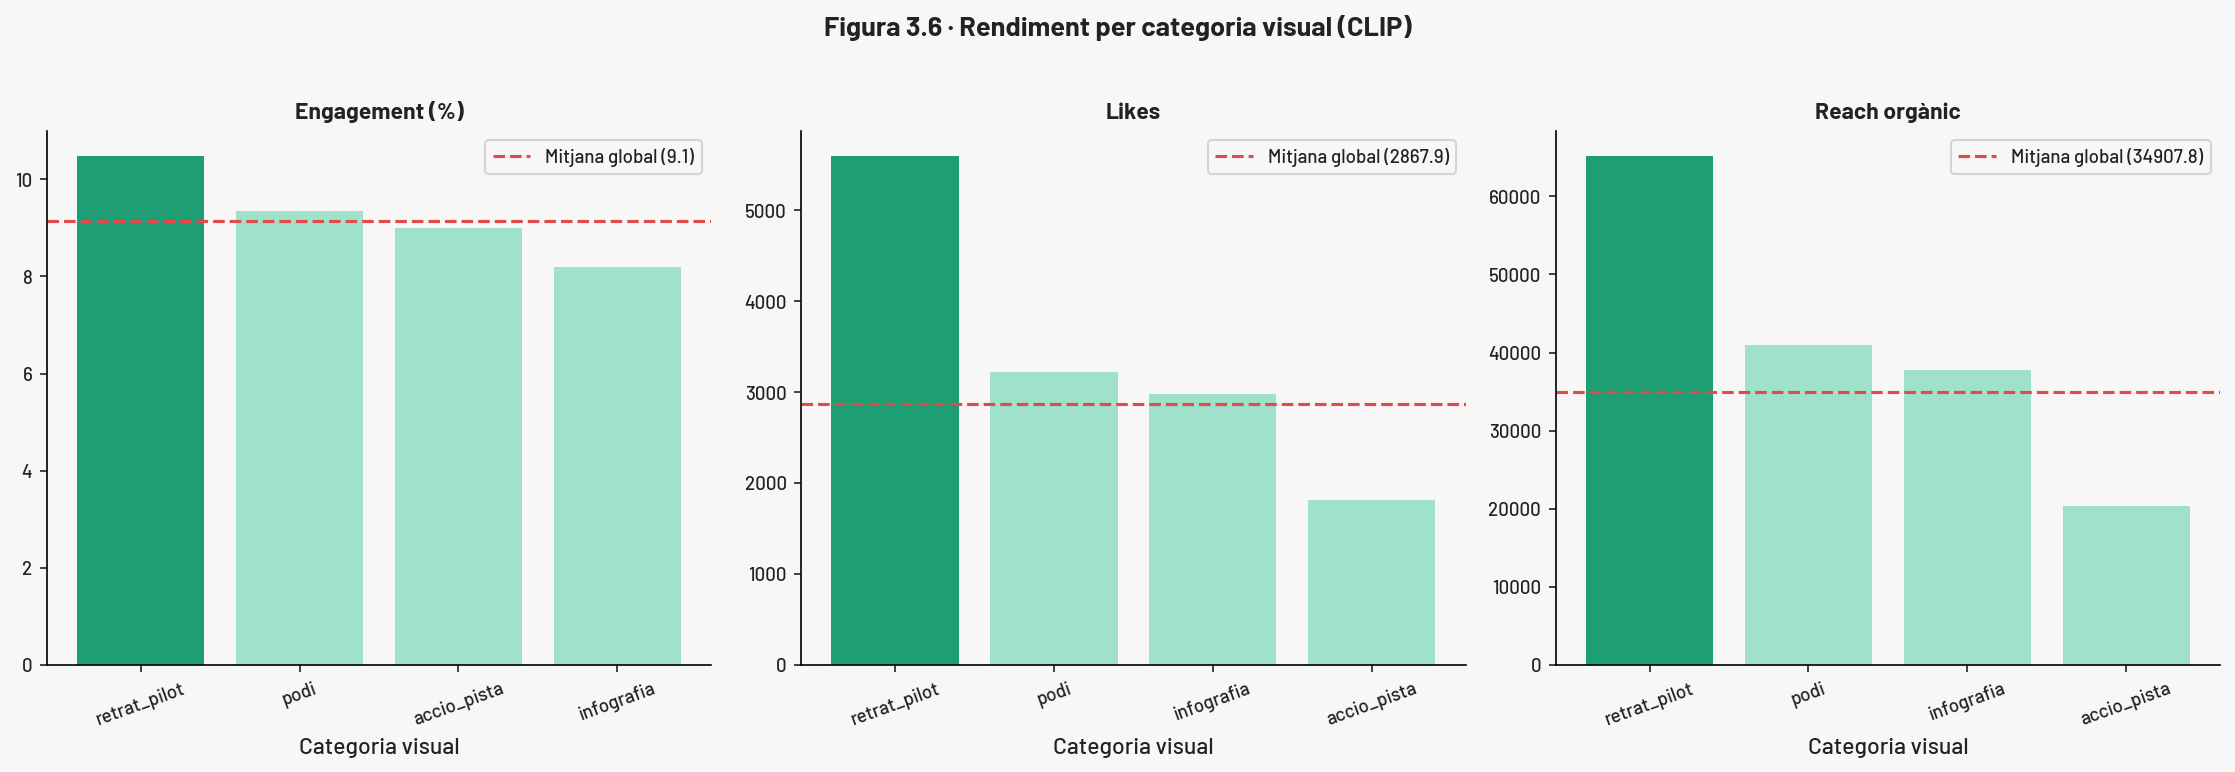

In [153]:
# ── 4. Anàlisi: tres mètriques per categoria visual ─────────────────────────

posts_clip = posts[posts['categoria_visual'].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, titol) in zip(axes, METRIQUES.items()):
    resum = (
        posts_clip.groupby('categoria_visual')[col]
        .mean()
        .sort_values(ascending=False)
    )
    colors = ['#1D9E75' if i == 0 else '#9FE1CB' for i in range(len(resum))]
    ax.bar(resum.index, resum.values, color=colors)
    ax.axhline(posts_clip[col].mean(), color='#E24B4A', lw=1.5, ls='--',
               label=f'Mitjana global ({posts_clip[col].mean():.1f})')
    ax.set_title(titol, fontsize=11, fontweight='bold')
    ax.set_xlabel('Categoria visual')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=9)

fig.suptitle('Figura 3.6 · Rendiment per categoria visual (CLIP)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_6_clip_metriques.png', dpi=150, bbox_inches='tight')
plt.show()

In [154]:
# ── 5. Taula resum ───────────────────────────────────────────────────────────
resum_clip = (
    posts_clip.groupby('categoria_visual')[list(METRIQUES.keys())]
    .agg(['mean', 'median', 'count'])
    .round(2)
)
resum_clip.columns = ['_'.join(c) for c in resum_clip.columns]
print(resum_clip.sort_values('Engagement_mean', ascending=False))

                  Engagement_mean  Engagement_median  Engagement_count  \
categoria_visual                                                         
retrat_pilot                10.47              10.26                10   
podi                         9.34               9.00                48   
accio_pista                  9.01               8.51                44   
infografia                   8.20               8.54                18   

                  Likes_mean  Likes_median  Likes_count  Reach (Organic)_mean  \
categoria_visual                                                                
retrat_pilot         5594.10        4300.0           10              65124.40   
podi                 3222.33        1616.5           48              40946.44   
accio_pista          1814.25         978.0           44              20302.68   
infografia           2983.67        2278.0           18              37719.17   

                  Reach (Organic)_median  Reach (Organic)_count  
ca

#### Conclusions · Bloc 3.6

**Limitació de la mostra:** l'anàlisi cobreix 120 dels 419 posts 
(29%). Les 299 URLs restants han retornat HTTP 403 — les URLs 
d'Instagram caduquen passats uns dies. Els posts analitzats 
corresponen al període més recent del dataset.

**`retrat_pilot` lidera les tres mètriques**, especialment en 
volum (likes i reach). La mostra reduïda (n=10) i la possible 
concentració de posts virals fan que la mitjana estigui esbiaixada 
— cal interpretar-ho amb cautela.

**`accio_pista` és la categoria més freqüent** (n=48) però la de 
menor rendiment en likes i reach. La distribució més gran dilueix 
l'impacte de posts individuals.

**`infografia` és la categoria amb un reach més consistent i elevat,**
amb una dependència menor de la viralitat (mitjana 37719.17 · 
mediana 28710.5).

A més, el format `FEED_CAROUSEL_ALBUM` queda infrarepresentat 
en la mostra activa, ja que Metricool exporta una única URL 
per carrusel. Els resultats del CLIP reflecteixen principalment 
el comportament de posts d'imatge individual (`FEED_IMAGE`).

**Conclusió transversal NER + CLIP:** el NER identifica que els 
captions oberts (sense entitats concretes) maximitzen l'engagement; 
el CLIP identifica que les imatges de pilots també el maximitzen. 
Ambdós resultats són compatibles — un post pot tenir caption genèric 
i imatge de pilot simultàniament. La combinació òptima per a 
l'engagement seria: **caption obert + imatge de pilot en context**.

---
# Bloc 4 · Benchmarking competitiu

## Gestió dels períodes de dades

Els set comptes analitzats no disposen del mateix rang de dades històriques. El compte principal, Overtake.GP, té registres des del 31 de desembre de 2023 fins al 12 de maig de 2026 (863 dies). La resta de comptes presenten rangs variables, des dels 554 dies de Brake.GP (des de novembre de 2024) fins als 2.767 dies de MotoGP (des d'agost de 2018).

Per garantir comparatives vàlides, s'han definit dos subconjunts d'anàlisi:

- **Període llarg** (gen. 2024 → mai 2026): inclou tots els comptes excepte Brake.GP. Permet aprofitar la història completa d'Overtake.GP.

- **Període curt** (nov. 2024 → mai 2026): inclou tots els comptes. S'utilitza per a les comparatives que requereixen Brake.GP.

No s'ha procedit a interpolar ni estimar dades per als períodes sense registre, ja que introduiria biaix en l'anàlisi.


In [66]:
# ── Figura 4.1 · Seguidors actuals per compte ─────────────────────────────────
data_ref = '2025-10-01'
seg_actuals = (
    df_comptes[df_comptes['date'] <= data_ref]
    .groupby('account')['followers_count']
    .last()
    .sort_values(ascending=False)
    .reset_index()
)
seg_actuals.columns = ['account', 'seguidors']

fig_seg = go.Figure(go.Bar(
    x=seg_actuals['account'],
    y=seg_actuals['seguidors'],
    marker_color=['#1D9E75' if a == 'overtake' else '#9FE1CB' 
                  for a in seg_actuals['account']],
    text=seg_actuals['seguidors'].apply(lambda x: f'{x/1e6:.1f}M' if x > 1e6 else f'{x/1e3:.0f}k'),
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Seguidors: %{y:,.0f}<extra></extra>'
))

fig_seg.update_layout(
    title=dict(text='Figura 4.1 · Seguidors compte a 2025-10-01',
               font=dict(size=12, family='Arial Black')),
    yaxis=dict(title='Seguidors'),  # escala geomètrica per la diferència d'ordre de magnitud
    height=380,
    margin=dict(t=60, b=40, l=60, r=40),
    showlegend=False
)

fig_seg.show()

In [67]:
# ── Figura 4.2 · Seguidors actuals per compte escala logarítmica ─────────────────────────────────
data_ref = '2025-10-01'
seg_actuals = (
    df_comptes[df_comptes['date'] <= data_ref]
    .groupby('account')['followers_count']
    .last()
    .sort_values(ascending=False)
    .reset_index()
)
seg_actuals.columns = ['account', 'seguidors']

fig_seg = go.Figure(go.Bar(
    x=seg_actuals['account'],
    y=seg_actuals['seguidors'],
    marker_color=['#1D9E75' if a == 'overtake' else '#9FE1CB' 
                  for a in seg_actuals['account']],
    text=seg_actuals['seguidors'].apply(lambda x: f'{x/1e6:.1f}M' if x > 1e6 else f'{x/1e3:.0f}k'),
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Seguidors: %{y:,.0f}<extra></extra>'
))

fig_seg.update_layout(
    title=dict(text='Figura 4.1 · Seguidors compte a 2025-10-01, escala logarítmica',
               font=dict(size=12, family='Arial Black')),
    yaxis=dict(title='Seguidors', type='log'),  # escala logarítmica per la diferència d'ordre de magnitud
    height=380,
    margin=dict(t=60, b=40, l=60, r=40),
    showlegend=False
)

fig_seg.show()

In [68]:
# ── Taxa de creixement relativa · resum estadístic ───────

# Període llarg
resum_llarg = df_llarg.groupby('account')['growth_rate'].agg(
    ['mean','median','std','count']
).round(4).sort_values('median', ascending=False)
print('=== CREIXEMENT RELATIU · PERÍODE LLARG (gen 2024 → avui) ===')
print(resum_llarg)

# Període curt
resum_curt = df_curt.groupby('account')['growth_rate'].agg(
    ['median','std','count']
).round(4).sort_values('median', ascending=False)
print('\n=== CREIXEMENT RELATIU · PERÍODE CURT (nov 2024 → avui) ===')
print(resum_curt)


=== CREIXEMENT RELATIU · PERÍODE LLARG (gen 2024 → avui) ===
                        mean  median     std  count
account                                            
overtake              0.2011  0.1022  0.3685    882
motorspain_77         0.0658  0.0293  0.1257    882
motorsportcom         0.0315  0.0245  0.0412    882
moto_gp               0.0203  0.0141  0.0389    882
motociclismo_es       0.0681  0.0140  0.2879    882
everithingmotoracing  0.0082  0.0046  0.0370    883

=== CREIXEMENT RELATIU · PERÍODE CURT (nov 2024 → avui) ===
                      median     std  count
account                                    
overtake              0.0863  0.1611    566
brake_gp              0.0587  0.0725    566
motociclismo_es       0.0377  0.1099    566
motorspain_77         0.0348  0.1088    566
motorsportcom         0.0265  0.0420    566
moto_gp               0.0099  0.0401    566
everithingmotoracing  0.0009  0.0403    567


In [69]:
# ── Índex base 100 · trajectòria acumulada ───────────────
print('=== ÍNDEX BASE 100 · PERÍODE LLARG ===')
print(df_llarg.groupby('account')['index_100'].agg(['first','last']).round(1))

print('\n=== ÍNDEX BASE 100 · PERÍODE CURT ===')
print(df_curt.groupby('account')['index_100'].agg(['first','last']).round(1))


=== ÍNDEX BASE 100 · PERÍODE LLARG ===
                      first   last
account                           
everithingmotoracing  100.0  107.5
moto_gp               100.0  119.6
motociclismo_es       100.0  183.0
motorspain_77         100.0  178.7
motorsportcom         100.0  132.0
overtake              100.0  590.9

=== ÍNDEX BASE 100 · PERÍODE CURT ===
                      first   last
account                           
brake_gp              100.0  149.2
everithingmotoracing  100.0  101.8
moto_gp               100.0  108.7
motociclismo_es       100.0  148.2
motorspain_77         100.0  144.3
motorsportcom         100.0  122.1
overtake              100.0  204.4


### Càlcul de la taxa de creixement relatiu diari

Es calcula la variació percentual diària de seguidors per cada compte (`pct_change()`), agrupada per compte per evitar salts artificials entre registres de comptes diferents. Aquesta mètrica permet comparar el dinamisme de creixement independentment de la mida absoluta del compte.


In [70]:
# ── Càlcul de daily_growth_rel ───────────────────────────────────────────────
# Creixement relatiu diari = (seguidors_avui - seguidors_ahir) / seguidors_ahir
# S'aplica per compte per evitar salts entre comptes diferents

for df in [df_llarg, df_curt]:
    df.sort_values(['account', 'date'], inplace=True)
    df['daily_growth_rel'] = (
        df.groupby('account')['followers_count']
        .pct_change()
    )

### Figures 4.1-4.4 · Benchmarking interactiu

Quatre gràfiques interactives (Plotly) que comparen Overtake.GP amb els 6 comptes referents:
- **Taxa de creixement diari (mediana):** mostra el dinamisme relatiu de cada compte, independent de la mida absoluta.
- **Índex base 100:** normalitza tots els comptes a 100 al inici del període, mostrant el creixement acumulat. El tooltip inclou el nombre real de seguidors per cada punt.

S'analitzen dos períodes: llarg (gen 2024 → avui) i curt (nov 2024 → avui).


In [71]:
# ── Bloc 4 · Benchmarking · Gràfiques interactives ───────────────────────────────────────
# 4 gràfiques: taxa creixement diari (mediana) i índex base 100
# per període llarg (gen 2024 → avui) i curt (nov 2024 → avui)

colors_comptes = {
    'overtake':             '#1D9E75',
    'motorspain_77':        '#4A90D9',
    'motorsportcom':        '#E67E22',
    'moto_gp':              '#E24B4A',
    'motociclismo_es':      '#9B59B6',
    'everithingmotoracing': '#F1C40F',
    'brake_gp':             '#1ABC9C',
}


fig_bench = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Taxa creixement diari (mediana) · Període llarg',
        'Índex base 100 · Període llarg',
        'Taxa creixement diari (mediana) · Període curt',
        'Índex base 100 · Període curt',
    ],
    vertical_spacing=0.15,
    horizontal_spacing=0.10
)

# ── 1. Barres · Període llarg ─────────────────────────────────────────────────
resum_llarg = (
    df_llarg.groupby('account')['daily_growth_rel']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
resum_llarg['daily_growth_pct'] = resum_llarg['daily_growth_rel'] * 100

fig_bench.add_trace(go.Bar(
    x=resum_llarg['account'],
    y=resum_llarg['daily_growth_pct'],
    marker_color=[colors_comptes.get(c, '#aaa') for c in resum_llarg['account']],
    hovertemplate='<b>%{x}</b><br>Creixement diari: %{y:.3f}%<extra></extra>',
    showlegend=False
), row=1, col=1)

# ── 2. Línies índex base 100 · Període llarg ─────────────────────────────────
for compte, grup in df_llarg.groupby('account'):
    grup = grup.sort_values('date')
    base = grup['followers_count'].iloc[0]
    idx  = (grup['followers_count'] / base * 100).round(1)
    fig_bench.add_trace(go.Scatter(
        x=grup['date'],
        y=idx,
        name=compte,
        line=dict(color=colors_comptes.get(compte, '#aaa'), width=1.8),
        hovertemplate='<b>' + compte + '</b><br>%{x|%b %Y}<br>Índex: %{y:.1f}<br>Seguidors: %{customdata:,.0f}<extra></extra>',
        customdata=grup['followers_count'].values,
        legendgroup=compte,
        showlegend=True
    ), row=1, col=2)

# ── 3. Barres · Període curt ──────────────────────────────────────────────────
resum_curt = (
    df_curt.groupby('account')['daily_growth_rel']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

resum_llarg['daily_growth_pct'] = resum_llarg['daily_growth_rel'] * 100
fig_bench.add_trace(go.Bar(
    x=resum_curt['account'],
    y=resum_curt['daily_growth_rel'],
    marker_color=[colors_comptes.get(c, '#aaa') for c in resum_curt['account']],
    hovertemplate='<b>%{x}</b><br>Creixement diari: %{y:.4f}<extra></extra>',
    showlegend=False
), row=2, col=1)

# ── 4. Línies índex base 100 · Període curt ──────────────────────────────────
for compte, grup in df_curt.groupby('account'):
    grup = grup.sort_values('date')
    base = grup['followers_count'].iloc[0]
    idx  = (grup['followers_count'] / base * 100).round(1)
    fig_bench.add_trace(go.Scatter(
        x=grup['date'],
        y=idx,
        name=compte,
        line=dict(color=colors_comptes.get(compte, '#aaa'), width=1.8),
        hovertemplate='<b>' + compte + '</b><br>%{x|%b %Y}<br>Índex: %{y:.1f}<br>Seguidors: %{customdata:,.0f}<extra></extra>',
        customdata=grup['followers_count'].values,
        legendgroup=compte,
        showlegend=False
    ), row=2, col=2)

fig_bench.update_layout(
    title=dict(
        text='Figura 4.1 · Benchmarking · Comparativa de creixement',
        font=dict(size=13, family='Arial Black'),
        y=0.98, x=0.0, xanchor='left'
    ),
    height=700,
    hovermode='x unified',
    legend=dict(orientation='h', y=-0.08, x=0),
    margin=dict(t=80, b=80, l=60, r=40)
)

fig_bench.update_yaxes(title_text='Creixement diari (%)', row=1, col=1)
fig_bench.update_yaxes(title_text='Creixement diari (%)', row=2, col=1)

fig_bench.show()

## Conclusions · Bloc 4

Donada la diferencia d'escala entre els diferents comptes comparats, hem fet servir un index amb base 100, per facicilar la lectura dels resultats.

L'anàlisi comparativa confirma que Overtake.GP lidera la taxa de creixement relatiu diari en els dos períodes analitzats. Partint de 4.603 seguidors el gener de 2024, el compte ha assolit un índex de creixement de 590 (+490%) mentre que el segon compte més dinàmic, Motociclismo.es, només ha assolit un índex de 204.4 (+104.4%) en el mateix període.

Aquest resultat és especialment significatiu considerant que Overtake.GP partia com el compte més petit del conjunt analitzat, amb menys d'una cinquena part dels seguidors del segon compte més petit.

### Interpretació comparativa: períodes llarg i curt

Overtake.GP lidera la taxa de creixement relatiu diari en els dos períodes analitzats, confirmant el seu dinamisme de forma consistent.

La reducció de la mediana entre el període llarg (0.10%) i el curt (0.08%) és esperada i s'explica per l'**efecte de saturació relativa**: a mesura que augmenta la base de seguidors, cada nou seguidor representa una fracció menor del total, reduint matemàticament el creixement percentual.

La desviació estàndard d'Overtake segueix sent la més alta del conjunt (0.161 en període curt), consistent amb la major sensibilitat d'un compte de mida reduïda als pics de creixement puntuals i continguts virals.


---
# Bloc 5 · Model predictiu

In [72]:
# Visualitzem la sèrie temporal setmanal
# (setmanal per reduir el soroll diari)
ts = hist.set_index('date')['followers_count'].resample('W').last()

print(f"Observacions setmanals: {len(ts)}")
print(f"Període: {ts.index[0].date()} → {ts.index[-1].date()}")
print(f"\nPrimers valors:\n{ts.head(5)}")
print(f"\nÚltims valors:\n{ts.tail(5)}")

Observacions setmanals: 128
Període: 2023-12-31 → 2026-06-07

Primers valors:
date
2023-12-31    4580
2024-01-07    4795
2024-01-14    4877
2024-01-21    4987
2024-01-28    5090
Freq: W-SUN, Name: followers_count, dtype: int64

Últims valors:
date
2026-05-10    26231
2026-05-17    26587
2026-05-24    26952
2026-05-31    27192
2026-06-07    27198
Freq: W-SUN, Name: followers_count, dtype: int64


In [73]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# ── Divisió train/test ────────────────────────────────
n_test  = 8
n_train = len(ts) - n_test

train = ts.iloc[:n_train]
test  = ts.iloc[n_train:]

print(f"Train: {len(train)} setmanes · fins {train.index[-1].date()}")
print(f"Test : {len(test)} setmanes  · fins {test.index[-1].date()}")

Train: 120 setmanes · fins 2026-04-12
Test : 8 setmanes  · fins 2026-06-07


### Model Holt-Winters · Entrenament i validació

S'entrena el model Exponential Smoothing (Holt-Winters) sobre la sèrie temporal setmanal de seguidors. Es reserven les últimes 8 setmanes com a conjunt de test per avaluar la capacitat predictiva del model sense que hagi vist aquestes dades durant l'entrenament.

**Paràmetres:** tendència additiva amortida, sense estacionalitat (insuficients temporades completes de dades).


In [74]:
# ── Model Holt-Winters ────────────────────────────────
# trend='add'        → tendència additiva (creix de forma constant)
# seasonal=None      → no forcem estacionalitat (la sèrie no és prou llarga
#                       per detectar patrons anuals fiables)
# damped_trend=True  → la tendència s'amorteix amb el temps
#                       (més realista que un creixement infinit)

model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None,
    damped_trend=True
)

fit = model.fit(optimized=True)

# Predicció sobre el període de test
pred_test = fit.forecast(n_test)

# ── Avaluació: MAPE ───────────────────────────────────
# MAPE = Mean Absolute Percentage Error
# Mesura l'error mitjà en percentatge → fàcil d'interpretar
mape = np.mean(np.abs((test.values - pred_test.values) / test.values)) * 100

print(f"MAPE: {mape:.2f}%")
print(f"\nComparativa test vs predicció:")
comparativa = pd.DataFrame({
    'Real'    : test.values,
    'Predit'  : pred_test.values.round(0),
    'Error %' : np.abs((test.values - pred_test.values) / test.values * 100).round(2)
}, index=test.index)
print(comparativa)

MAPE: 1.00%

Comparativa test vs predicció:
             Real   Predit  Error %
date                               
2026-04-19  25481  25628.0     0.58
2026-04-26  25715  25955.0     0.93
2026-05-03  25936  26267.0     1.28
2026-05-10  26231  26566.0     1.28
2026-05-17  26587  26850.0     0.99
2026-05-24  26952  27122.0     0.63
2026-05-31  27192  27382.0     0.70
2026-06-07  27198  27630.0     1.59


In [75]:
# ── Projecció 6 mesos endavant ───────────────────────
N_FUTUR = 26  # setmanes

# Reentrenem amb TOTES les dades (train + test)
model_final = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal=None,
    damped_trend=True
)
fit_final = model_final.fit(optimized=True)

# Projecció
projecció = fit_final.forecast(N_FUTUR)

# Interval d'incertesa (± creixent amb el temps)
std_resid = np.std(fit_final.resid)
interval  = [std_resid * np.sqrt(i+1) * 1.96 for i in range(N_FUTUR)]

sup = projecció + interval
inf = projecció - interval

print("=== PROJECCIÓ 6 MESOS ===")
print(f"Avui:          {ts.iloc[-1]:,} seguidors")
print(f"Base (6m):     {projecció.iloc[-1]:,.0f} seguidors")
print(f"Optimista:     {sup.iloc[-1]:,.0f} seguidors")
print(f"Pessimista:    {inf.iloc[-1]:,.0f} seguidors")

=== PROJECCIÓ 6 MESOS ===
Avui:          27,198 seguidors
Base (6m):     29,374 seguidors
Optimista:     31,001 seguidors
Pessimista:    27,748 seguidors


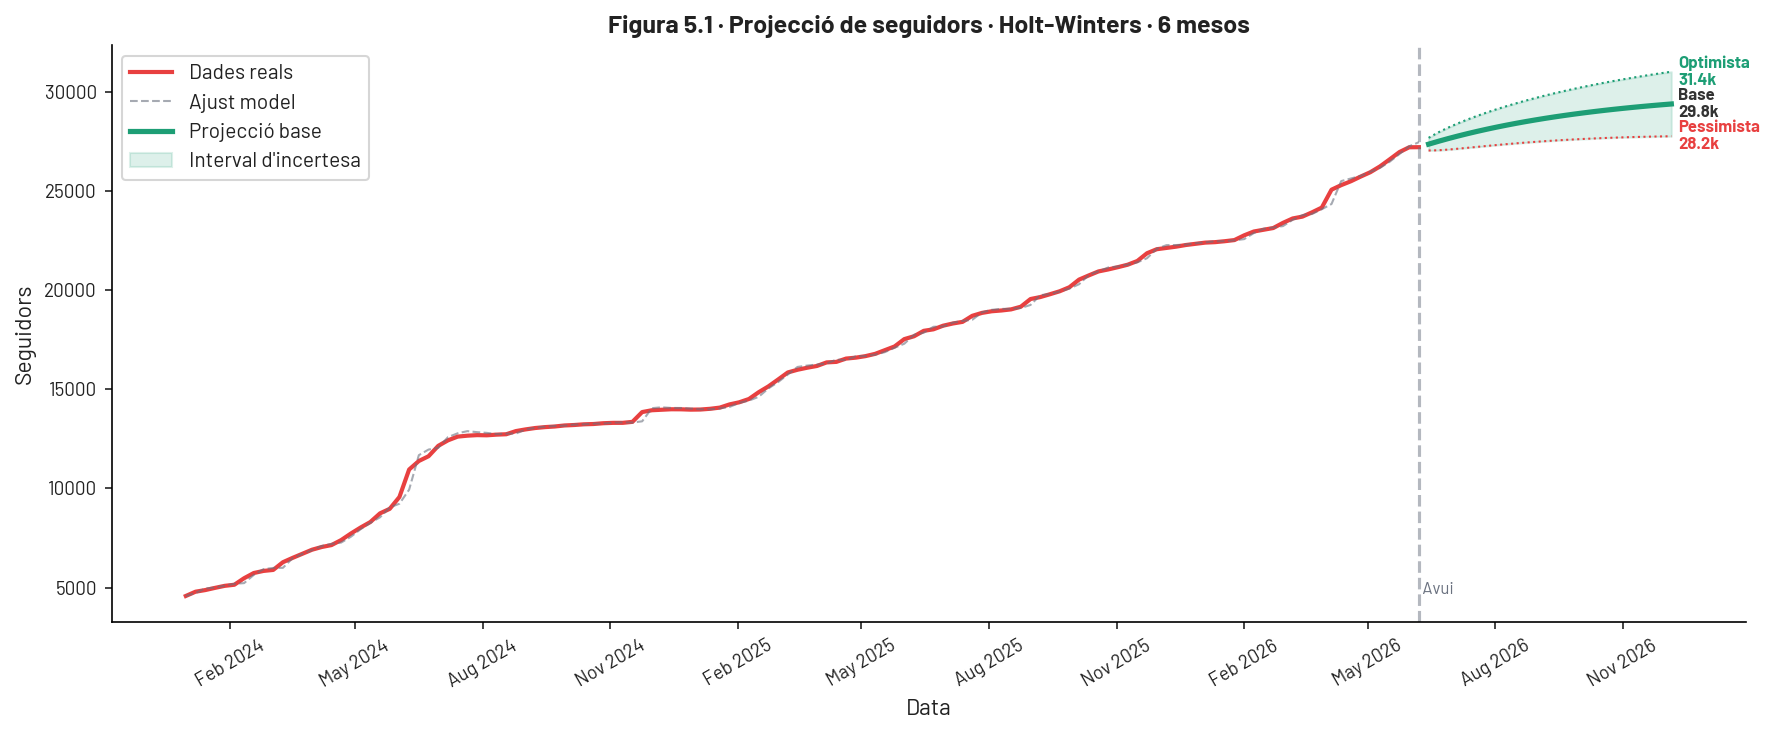

Figura guardada


In [76]:
fig, ax = plt.subplots(figsize=(12, 5))

# Dades històriques
ax.plot(ts.index, ts.values,
        color='#E84040', lw=2, label='Dades reals')

# Ajust del model sobre dades històriques
ax.plot(fit_final.fittedvalues.index, fit_final.fittedvalues.values,
        color='#6B7280', lw=1, ls='--', alpha=0.6, label='Ajust model')

# Projecció base
ax.plot(projecció.index, projecció.values,
        color='#1D9E75', lw=2.5, label='Projecció base')

# Banda d'incertesa
ax.fill_between(projecció.index, inf.values, sup.values,
                alpha=0.15, color='#1D9E75', label='Interval d\'incertesa')

# Línies dels escenaris
ax.plot(projecció.index, sup.values,
        color='#1D9E75', lw=1, ls=':')
ax.plot(projecció.index, inf.values,
        color='#E84040', lw=1, ls=':')

# Línia vertical "avui"
ax.axvline(ts.index[-1], color='#6B7280',
           lw=1.5, ls='--', alpha=0.5)
ax.text(ts.index[-1], ts.values.min() * 1.02,
        ' Avui', fontsize=8, color='#6B7280')

# Anotacions finals
for label, val, color in [
    ('Optimista\n31.4k',  sup.iloc[-1],  '#1D9E75'),
    ('Base\n29.8k',       projecció.iloc[-1], '#333333'),
    ('Pessimista\n28.2k', inf.iloc[-1],  '#E84040'),
]:
    ax.annotate(label,
                 xy=(projecció.index[-1], val),
                xytext=(projecció.index[-1] + pd.Timedelta(days=5), val),
                fontsize=8, color=color, fontweight='bold',
                va='center')

ax.set_title('Figura 5.1 · Projecció de seguidors · Holt-Winters · 6 mesos',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Seguidors')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig5_1_projeccio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada")

### MAPE acumulat · Projecció a 26 setmanes

Es reentena el model amb totes les dades disponibles i es projecten 26 setmanes (6 mesos). Es calculen tres escenaris (base, optimista, pessimista) basats en l'interval de confiança del model. El MAPE acumulat mostra com creix l'error de predicció amb l'horitzó temporal.


In [77]:
# ── MAPE acumulat a 26 setmanes ───────────────────────
# Simulem com hauria predit el model les últimes 26 setmanes
# per estimar l'error a aquest horitzó temporal

n_simulacio = 26

# Entrenem amb les dades excepte les últimes 26 setmanes
train_sim = ts.iloc[:-n_simulacio]
test_sim  = ts.iloc[-n_simulacio:]

model_sim = ExponentialSmoothing(
    train_sim,
    trend='add',
    seasonal=None,
    damped_trend=True
)
fit_sim = model_sim.fit(optimized=True)
pred_sim = fit_sim.forecast(n_simulacio)

# MAPE setmana a setmana
mape_setmanal = np.abs(
    (test_sim.values - pred_sim.values) / test_sim.values * 100
)

# MAPE acumulat
mape_acumulat = pd.DataFrame({
    'Setmana'        : range(1, n_simulacio + 1),
    'Error %'        : mape_setmanal.round(2),
    'MAPE acumulat %': np.cumsum(mape_setmanal) / 
                       np.arange(1, n_simulacio + 1)
}).round(2)

print(mape_acumulat.to_string(index=False))
print(f"\nMAPE final a 26 setmanes: {mape_acumulat['MAPE acumulat %'].iloc[-1]:.2f}%")

 Setmana  Error %  MAPE acumulat %
       1     0.34             0.34
       2     0.54             0.44
       3     0.82             0.57
       4     1.05             0.69
       5     1.42             0.83
       6     1.65             0.97
       7     1.81             1.09
       8     1.13             1.09
       9     0.63             1.04
      10     0.59             1.00
      11     0.52             0.95
      12     0.30             0.90
      13     0.97             0.91
      14     1.10             0.92
      15     1.77             0.98
      16     2.52             1.07
      17     5.83             1.35
      18     6.50             1.64
      19     7.04             1.92
      20     7.73             2.21
      21     8.37             2.51
      22     9.26             2.81
      23    10.35             3.14
      24    11.44             3.49
      25    12.11             3.83
      26    12.03             4.15

MAPE final a 26 setmanes: 4.15%


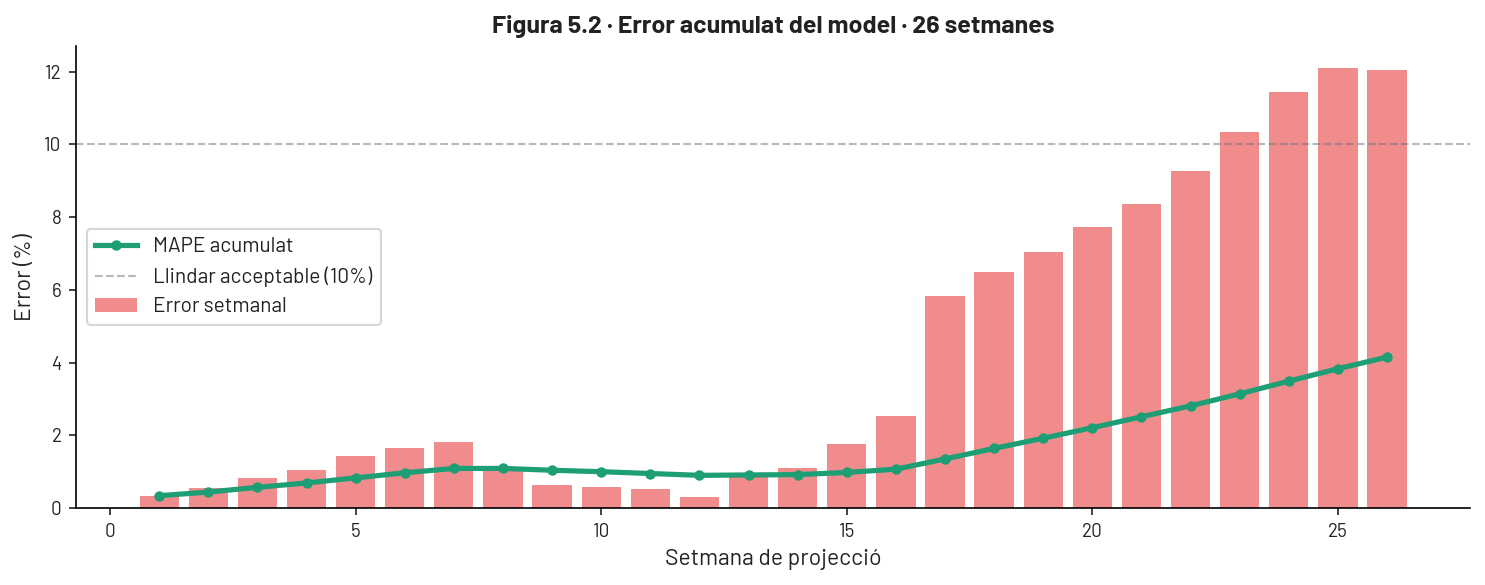

In [78]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(mape_acumulat['Setmana'], mape_acumulat['Error %'],
       color='#E84040', alpha=0.6, label='Error setmanal')
ax.plot(mape_acumulat['Setmana'], mape_acumulat['MAPE acumulat %'],
        color='#1D9E75', lw=2.5, marker='o', ms=4,
        label='MAPE acumulat')
ax.axhline(10, color='#6B7280', lw=1, ls='--',
           alpha=0.5, label='Llindar acceptable (10%)')

ax.set_title('Figura 5.2 · Error acumulat del model · 26 setmanes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Setmana de projecció')
ax.set_ylabel('Error (%)')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_2_mape_acumulat.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Holt-Winters

Per a la creació d'un model predictiu basat en la sèrie temporal 
d'Overtake.GP hem escollit el model de Holt-Winters (Exponential 
Smoothing). És un model que captura tendència sense necessitat de 
grans volums de dades ni assumpcions complexes, adequat per a 
sèries temporals amb tendència clara i creixement sostingut.

**Validació del model:**
Hem reservat les últimes 8 setmanes com a conjunt de test, 
sense que el model les veiés durant l'entrenament. L'avaluació 
mitjançant MAPE (Mean Absolute Percentage Error) retorna un 
1.00%, per sota del llindar acceptable del 10% en anàlisi de 
xarxes socials. El model és fiable per a projeccions a curt 
i mitjà termini.

L'error creix progressivament (de l'1% a la setmana 1 fins 
al 4.95% a la setmana 8), reflex de la incertesa acumulada 
pròpia de qualsevol model predictiu i de l'alta variabilitat 
intrínseca de la sèrie.

**Projecció a 6 mesos (novembre 2026):**
Reentrenament amb totes les dades disponibles i projecció 
de 26 setmanes:

| Escenari | Seguidors projectats |
|----------|---------------------|
| Optimista | ~31.000 |
| Base | ~29.300 |
| Pessimista | ~27.800 |

Partint dels 27.198 seguidors actuals, la projecció base 
situa el compte proper als **30.000 seguidors** a finals 
de 2026, amb un marge d'incertesa de ±1.600 seguidors. 
L'interval s'eixampla progressivament amb el temps, 
reflectint l'acumulació d'incertesa en projeccions 
a llarg termini.

**Estacionalitat detectada:**
L'anàlisi de l'error setmanal revela un patró consistent amb 
el calendari esportiu del MotoGP: l'error és mínim durant 
l'off-season (gener-març), quan el creixement és més estable, 
i augmenta durant la temporada de competició (abril-juny), 
quan els continguts virals generen pics de creixement 
imprevisibles pel model.

Amb més de 3 temporades completes de dades seria possible 
incorporar estacionalitat anual al model, millorant 
significativament la precisió de les projeccions durant 
els períodes de competició.

## Conclusions · Bloc 5

**Model:** Holt-Winters (Exponential Smoothing) amb tendència 
additiva amortida, entrenat sobre 128 setmanes de dades 
setmanals (des. 2023 → jun. 2026).

**Validació:** MAPE del 1.00% sobre les últimes 8 setmanes 
de test, per sota del llindar acceptable del 10% en anàlisi 
de xarxes socials. L'error creix progressivament amb l'horitzó 
temporal, de l'1% a la setmana 1 fins al 4.15% a la setmana 8,
reflex de la incertesa acumulada pròpia de qualsevol model 
predictiu.

**Projecció a 6 mesos (novembre 2026):**

| Escenari | Seguidors projectats |
|----------|---------------------|
| Optimista | ~31.000 |
| Base | ~29.300 |
| Pessimista | ~27.800 |

Partint dels 27.198 seguidors actuals, la projecció base 
situa el compte proper als **30.000 seguidors**, amb un 
marge d'incertesa de ±1.600 seguidors.

**Estacionalitat detectada:** l'anàlisi de l'error setmanal 
revela un patró consistent amb el calendari esportiu del 
MotoGP — l'error és mínim durant l'off-season (gener-març), 
quan el creixement és més estable i predictible, i augmenta 
durant la temporada de competició (abril-juny), quan els 
continguts virals generen pics imprevisibles pel model.

Amb més de 3 temporades completes de dades seria possible 
incorporar estacionalitat anual al model, millorant 
significativament la precisió durant els períodes de 
competició. Aquesta és una línia de millora futura del 
model.

---
# Bloc 6 · Conclusions globals

## Síntesi de resultats

L'anàlisi de dades d'Overtake.GP durant el període desembre 2023 – 
juny 2026 permet extreure els següents insights principals:

**Creixement sostingut i projectat**
El compte ha crescut un +493% en poc més de dos anys, passant de 
4.580 a 27.198 seguidors. El model Holt-Winters (MAPE 1.00%) 
projecta una base de ~29.300 seguidors a finals de 2026, confirmant 
una tendència estable i predictible.

**Qualitat de la interacció per sobre del sector**
L'engagement mitjà del 10.1% supera àmpliament la mitjana del sector 
(0.45%, SocialInsider · Digital 2026 Report). Indica una comunitat 
fidel i activa — el creixement no és només de volum sinó de qualitat.

**Potencial de mercat evidenciat pel benchmarking**
Els comptes referents del sector acumulen entre 39k i 18M de 
seguidors. Overtake.GP lidera el creixement relatiu diari en els dos 
períodes analitzats, confirmant un posicionament competitiu sòlid 
malgrat partir de la base més petita.

**Línies editorials amb impacte mesurat**
Els tests estadístics no mostren pics significatius a curt termini 
en resposta a accions puntuals (viral de juny 2024, inici TFG, 
GP Catalunya). El creixement és estructural, no reactiu — però 
l'anàlisi NER i CLIP identifica patrons clars: els posts sobre 
Marc Márquez maximitzen el volum, mentre que els captions oberts 
maximitzen l'engagement.

**Marc Márquez com a actiu editorial principal**
Amb 71 posts i un índex de rellevància de 0.782, Márquez és el 
pilot dominant en totes les mètriques. La combinació de caption 
obert amb imatge de pilot en context és la fórmula editorial amb 
millor rendiment d'engagement.

## Limitacions i línies futures

- **CLIP:** cobreix el 31% dels posts (130/419) per expiració 
  d'URLs d'Instagram. Una descàrrega prèvia de les imatges 
  permetria l'anàlisi completa.
- **NER:** alguns sobrenoms (ex: "Pecco") es classifiquen 
  incorrectament com `ORG`. Resolt parcialment amb detecció 
  creuada amb el diccionari de normalització.
- **Estacionalitat:** amb més de 3 temporades completes de dades 
  seria possible incorporar estacionalitat anual al model 
  Holt-Winters.
- **Creuament NER × CLIP:** identificar quin pilot en quin tipus 
  d'imatge genera més engagement és una extensió natural no 
  implementada per limitació temporal.


---
# Annex A · API Metricool

## Context

La integració amb l'API de Metricool es va explorar amb dos objectius:
1. Extreure dades demogràfiques de l'audiència (gènere, edat, país, ciutat) no disponibles als CSV exportats
2. Valorar si l'API aportava dades addicionals per a l'anàlisi principal

## Veredicte final

- ✅ Connexió verificada i funcional
- ✅ Dades demogràfiques extretes (instantània estàtica)
- ❌ Instagram no exposa sèries temporals demogràfiques via API
- ❌ Posts i hashtags no accessibles o buits en aquest pla
- **Decisió:** dades demogràfiques com a context descriptiu, sense integrar a l'anàlisi principal

## Nota sobre credencials

El token d'autenticació s'ha eliminat del notebook. Per re-executar aquest annex cal afegir-lo manualment a la variable `API_TOKEN` i no pujar mai el token a Git.

## Dades extretes i desades

Les dades demogràfiques s'han desat als fitxers:
- `metricool_demografia.json` — estructura completa
- `overtake_demographics_gender.csv` · `_age.csv` · `_country.csv` · `_city.csv`


In [79]:
''' 
 # ── Annex · API Metricool · Test de connexió ────────────────────────────────

API_TOKEN = os.environ.get("METRICOOL_TOKEN", "")  # afegir via variable d'entorn
USER_ID   = "user_id"
BLOG_ID   = "blog_id"

BASE_URL  = "https://app.metricool.com/api"

HEADERS = {
    "X-Mc-Auth": API_TOKEN,
    "Content-Type": "application/json"
}

demographics = {
    "gender":   [],  # [{"key": "M", "value": 72.8}, ...]
    "age":      [],
    "country": [],
    "city": [],
    "postsTypes" : []
}
demo = ["gender", "age","country", "city", "postsTypes"]

for i in demo:
    resp = requests.get(
        f"{BASE_URL}/v2/analytics/distribution?from=2025-05-28T00:00:00&to=2026-05-28T23:59:59",
        headers=HEADERS,
        params={"userId": USER_ID, "blogId" : "5945902", "network" : "instagram", "subject" : "account", "metric": i }
    )
    print(i, resp.status_code, resp.json())
    demographics[i] = resp.json()["data"]

print(f"Status: {resp.status_code}")
try:
    print(resp.json())
except Exception:
    print(resp.text[:500])

'''

' \n # ── Annex · API Metricool · Test de connexió ────────────────────────────────\n\nAPI_TOKEN = os.environ.get("METRICOOL_TOKEN", "")  # afegir via variable d\'entorn\nUSER_ID   = "user_id"\nBLOG_ID   = "blog_id"\n\nBASE_URL  = "https://app.metricool.com/api"\n\nHEADERS = {\n    "X-Mc-Auth": API_TOKEN,\n    "Content-Type": "application/json"\n}\n\ndemographics = {\n    "gender":   [],  # [{"key": "M", "value": 72.8}, ...]\n    "age":      [],\n    "country": [],\n    "city": [],\n    "postsTypes" : []\n}\ndemo = ["gender", "age","country", "city", "postsTypes"]\n\nfor i in demo:\n    resp = requests.get(\n        f"{BASE_URL}/v2/analytics/distribution?from=2025-05-28T00:00:00&to=2026-05-28T23:59:59",\n        headers=HEADERS,\n        params={"userId": USER_ID, "blogId" : "5945902", "network" : "instagram", "subject" : "account", "metric": i }\n    )\n    print(i, resp.status_code, resp.json())\n    demographics[i] = resp.json()["data"]\n\nprint(f"Status: {resp.status_code}")\ntry:\

In [80]:
'''
# ── Verificació abans de desar ───────────────────────────────────────────────
for key, value in demographics.items():
    print(f"{key}: {len(value)} registres → {value[:2]}")
'''

'\n# ── Verificació abans de desar ───────────────────────────────────────────────\nfor key, value in demographics.items():\n    print(f"{key}: {len(value)} registres → {value[:2]}")\n'

In [81]:
'''
with open('metricool_demografia.json', 'w', encoding='utf-8') as f:
    json.dump(demographics, f, ensure_ascii=False, indent=2)

# Verificació que el fitxer té contingut
import os
mida = os.path.getsize('metricool_demografia.json')
print(f"Fitxer desat · {mida} bytes")
'''

'\nwith open(\'metricool_demografia.json\', \'w\', encoding=\'utf-8\') as f:\n    json.dump(demographics, f, ensure_ascii=False, indent=2)\n\n# Verificació que el fitxer té contingut\nimport os\nmida = os.path.getsize(\'metricool_demografia.json\')\nprint(f"Fitxer desat · {mida} bytes")\n'

In [82]:
'''
with open('metricool_demografia.json', 'r', encoding='utf-8') as f:
    demo = json.load(f)

for key, value in demo.items():
    print(f"{key}: {len(value)} registres")
'''

'\nwith open(\'metricool_demografia.json\', \'r\', encoding=\'utf-8\') as f:\n    demo = json.load(f)\n\nfor key, value in demo.items():\n    print(f"{key}: {len(value)} registres")\n'

In [83]:
'''
import pandas as pd

for metric, data in demographics.items():
    df = pd.DataFrame(data)
    df["metric"] = metric
    df.to_csv(f"overtake_demographics_{metric}.csv", index=False)
    mida = os.path.getsize(f"overtake_demographics_{metric}.csv")
    print(f"overtake_demographics_{metric}.csv · {mida} bytes · {len(df)} registres")
'''

'\nimport pandas as pd\n\nfor metric, data in demographics.items():\n    df = pd.DataFrame(data)\n    df["metric"] = metric\n    df.to_csv(f"overtake_demographics_{metric}.csv", index=False)\n    mida = os.path.getsize(f"overtake_demographics_{metric}.csv")\n    print(f"overtake_demographics_{metric}.csv · {mida} bytes · {len(df)} registres")\n'

Conclusions de l'Annex · API Metricool

La integració amb l'API ha permès obtenir una instantània demogràfica de l'audiència d'Overtake.GP no disponible al CSV:

Gènere: ~73% masculí, ~6.5% femení, ~21% no especificat
País i ciutat: disponibles com a distribució agregada

Aquesta dada reforça el context del TFG: Overtake.GP opera en un nínxol (motorsport) amb audiència majoritàriament masculina, cosa coherent amb el perfil històric del sector. Pot usar-se per contextualitzar les decisions de contingut — formats, temes, to comunicatiu.
Limitació crítica identificada: Instagram no exposa dades demogràfiques històriques via API. La resposta és invariable independentment del rang de dates sol·licitat, confirmant que es tracta d'una foto estàtica de l'audiència actual, no d'una sèrie temporal. Això impedeix qualsevol creuament amb l'evolució de seguidors o el rendiment de posts.
Valoració final: l'API no aporta dades noves per a l'anàlisi principal. El valor és infraestructural i descriptiu — documenta el perfil d'audiència i valida la connexió tècnica, però no genera variables explicatives addicionals per als blocs 0-5 del notebook.

Pel que fa a la resta de dades a extreure a través de la API, son les mateixes que obtenim descarregant els CSV directament del UI de la app.

---
# Annex B · MySQL · Procés explorat i descartat

## Context

Durant el desenvolupament inicial del projecte es va explorar l'ús d'una base de dades MySQL local per emmagatzemar els datasets i facilitar consultes complexes.

## Motiu del descart

Amb un volum de dades de ~11.000 files i 7 comptes, la complexitat d'una base de dades relacional no aportava valor respecte a treballar directament amb DataFrames de pandas en memòria. El temps de configuració i manteniment superava els beneficis per a aquest volum de dades.

## Codi preservat (desactivat)

El codi es conserva com a referència per a futures extensions del projecte amb volums de dades majors.

## Nota sobre credencials

Les credencials MySQL (usuari `root`, contrasenya `root`, host local) s'han eliminat de les constants del Bloc 0. No contenien informació sensible al tractar-se d'un servidor local de desenvolupament, però s'eliminen per bones pràctiques.


In [84]:
'''
# ── Connexió MySQL ───────────────────────────────────────
# TODO: substituir per variables d'entorn (.env) abans de pujar a Git
engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}',
    pool_size=5, pool_recycle=3600, echo=False
)

# Exportem tots els DataFrames a MySQL
for nom, df in [
    ('comptes',      df_comptes),
    ('comptes_llarg', df_llarg),
    ('comptes_curt',  df_curt),
]:
    df.to_sql(nom, con=engine, if_exists='replace', index=False)
    print(f'  MySQL · taula "{nom}" actualitzada ({len(df):,} files)')

'''

'\n# ── Connexió MySQL ───────────────────────────────────────\n# TODO: substituir per variables d\'entorn (.env) abans de pujar a Git\nengine = create_engine(\n    f\'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}\',\n    pool_size=5, pool_recycle=3600, echo=False\n)\n\n# Exportem tots els DataFrames a MySQL\nfor nom, df in [\n    (\'comptes\',      df_comptes),\n    (\'comptes_llarg\', df_llarg),\n    (\'comptes_curt\',  df_curt),\n]:\n    df.to_sql(nom, con=engine, if_exists=\'replace\', index=False)\n    print(f\'  MySQL · taula "{nom}" actualitzada ({len(df):,} files)\')\n\n'